In [ ]:

from google.colab import drive
drive.mount('/content/drive')

import zipfile
import os

# Path to your dataset zip file (update path as needed)
dataset_path = '/content/drive/MyDrive/DL_Assignment1_Dataset.zip'
extract_path = '/content/dataset'

# Extract dataset
if os.path.exists(dataset_path):
    with zipfile.ZipFile(dataset_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Dataset extracted successfully!")

    # List dataset structure
    print("\nDataset structure:")
    for root, dirs, files in os.walk(extract_path):
        level = root.replace(extract_path, '').count(os.sep)
        indent = ' ' * 2 * level
        print(f"{indent}{os.path.basename(root)}/")
        subindent = ' ' * 2 * (level + 1)
        for file in files[:5]:  # Show first 5 files
            print(f"{subindent}{file}")
        if len(files) > 5:
            print(f"{subindent}... and {len(files)-5} more files")
else:
    print(f"Dataset not found at {dataset_path}")
    print("Please upload the dataset to your Google Drive and update the path")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset extracted successfully!

Dataset structure:
dataset/
  Dataset/
    Dataset/
      annotations/
        4004_val.npy
        3039_exp.npy
        698_aro.npy
        2950_lnd.npy
        899_val.npy
        ... and 15991 more files
      images/
        5066.jpg
        4054.jpg
        1570.jpg
        4379.jpg
        4479.jpg
        ... and 3994 more files


In [ ]:

# Install additional packages if needed
!pip install -q krippendorff
!pip install -q scikit-image

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Deep Learning imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import VGG16, ResNet50, InceptionV3, MobileNetV2, EfficientNetB0, DenseNet121
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

# Sklearn imports
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, roc_auc_score
from sklearn.metrics import precision_recall_curve, auc, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr

# Set GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU Available: {len(gpus)} GPU(s)")
    except RuntimeError as e:
        print(e)

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

print("All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")


GPU Available: 1 GPU(s)
All libraries imported successfully!
TensorFlow version: 2.19.0


Loading facial expression dataset (corrected version)...
Images path: /content/dataset/Dataset/Dataset/images
Annotations path: /content/dataset/Dataset/Dataset/annotations
Found 15996 annotation files
Parsing annotation files...
Processed annotations for 3999 unique image IDs

Sample annotation inspection:

ID 4004:
  val: shape=(), dtype=<U9, sample_values=['-0.595238']
  lnd: shape=(136,), dtype=float64, sample_values=[18.0237037  67.52408511 20.55407407]
  aro: shape=(), dtype=<U9, sample_values=['-0.273915']
  exp: shape=(), dtype=<U1, sample_values=['2']

ID 3039:
  exp: shape=(), dtype=<U1, sample_values=['4']
  aro: shape=(), dtype=<U8, sample_values=['0.533662']
  val: shape=(), dtype=<U10, sample_values=['-0.0583355']
  lnd: shape=(136,), dtype=float64, sample_values=[15.485633   90.44262383 16.67095306]

ID 698:
  aro: shape=(), dtype=<U9, sample_values=['-0.293651']
  lnd: shape=(136,), dtype=float64, sample_values=[  8.66476987 117.98865672  15.11297071]
  val: shape=(), d

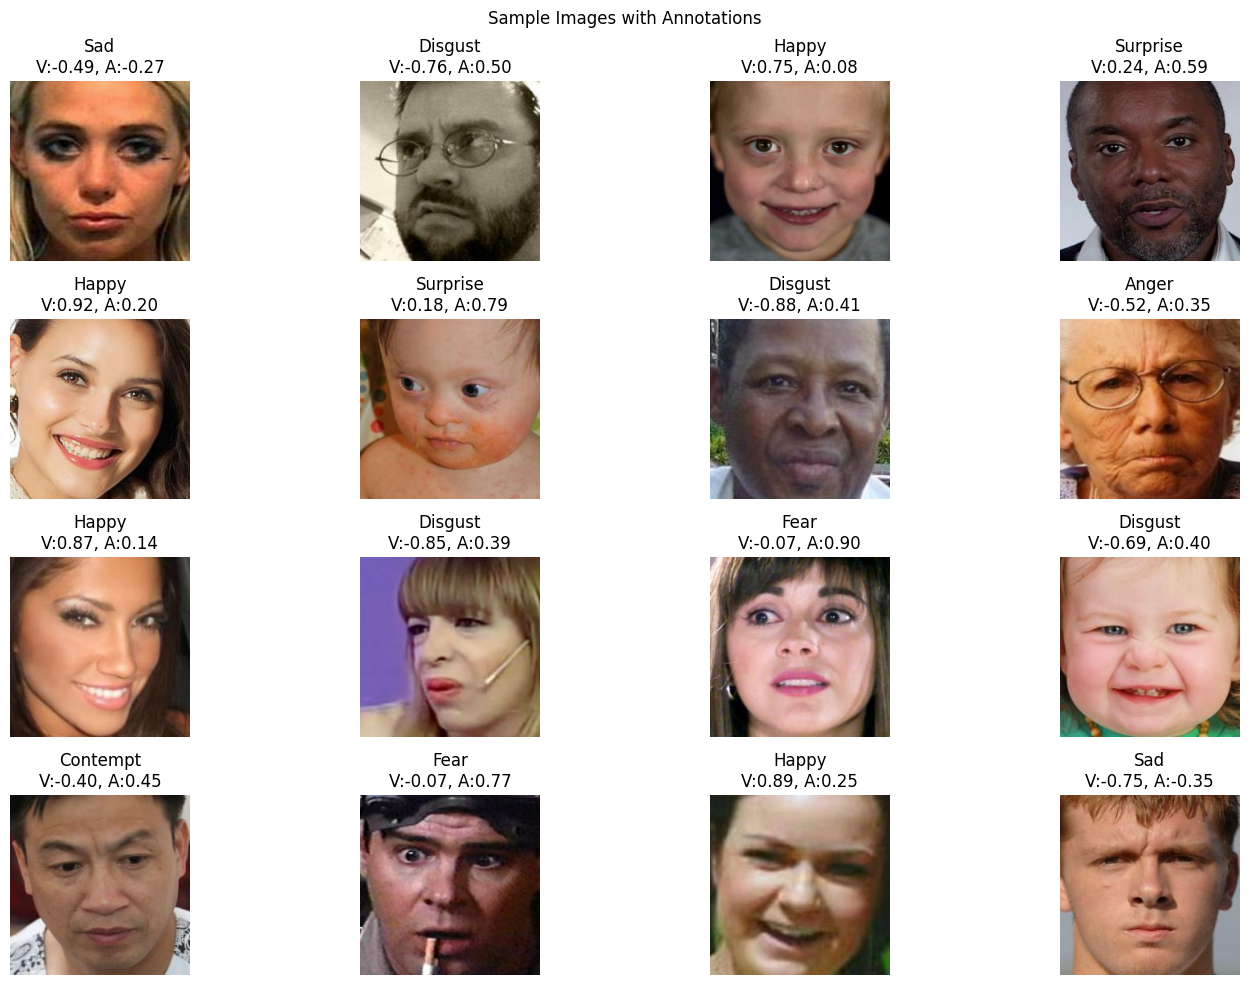

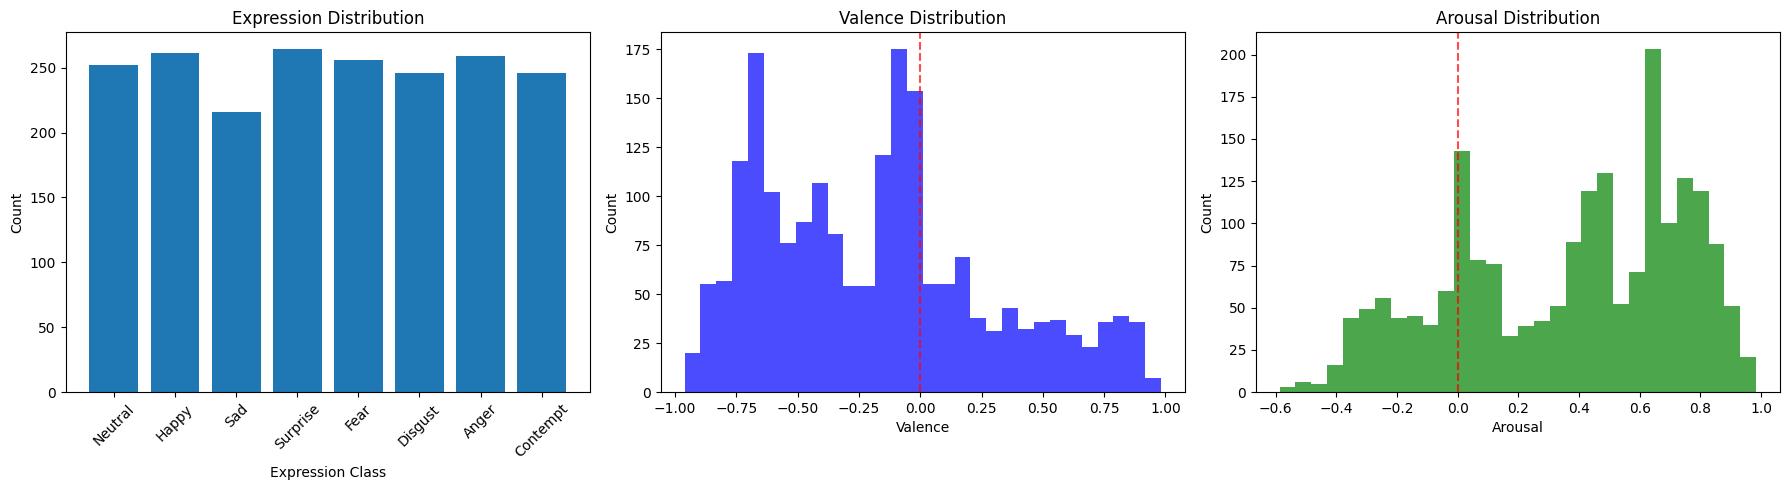


DATASET LOADED SUCCESSFULLY!
Ready to proceed with training using 2000 samples
You can now continue with the data splitting and model training steps.


In [ ]:
# ============================================================================
# FIXED DATASET LOADER - Properly handles your annotation format
# ============================================================================

import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from collections import defaultdict

def load_facial_expression_data_corrected(dataset_path):
    """
    Corrected loader for your specific dataset structure
    """
    print("Loading facial expression dataset (corrected version)...")

    # Your dataset structure: dataset/Dataset/Dataset/
    actual_dataset_path = os.path.join(dataset_path, 'Dataset', 'Dataset')
    images_path = os.path.join(actual_dataset_path, 'images')
    annotations_path = os.path.join(actual_dataset_path, 'annotations')

    print(f"Images path: {images_path}")
    print(f"Annotations path: {annotations_path}")

    if not os.path.exists(images_path) or not os.path.exists(annotations_path):
        print("Error: Could not find images or annotations directories!")
        return None, None, None, None

    # Get all annotation files
    annotation_files = [f for f in os.listdir(annotations_path) if f.endswith('.npy')]
    print(f"Found {len(annotation_files)} annotation files")

    # Parse annotations by type
    annotations_by_id = defaultdict(dict)

    print("Parsing annotation files...")
    for ann_file in annotation_files:
        try:
            # Parse filename: ID_type.npy (e.g., "4004_val.npy")
            parts = ann_file.replace('.npy', '').split('_')
            if len(parts) >= 2:
                img_id = parts[0]  # Keep as string for now
                ann_type = parts[1]  # exp, val, aro, lnd

                # Load the annotation data
                ann_path = os.path.join(annotations_path, ann_file)
                ann_data = np.load(ann_path)

                # Store the annotation
                annotations_by_id[img_id][ann_type] = ann_data

        except Exception as e:
            print(f"Error loading {ann_file}: {e}")
            continue

    print(f"Processed annotations for {len(annotations_by_id)} unique image IDs")

    # Check some sample annotations to understand the format
    print("\nSample annotation inspection:")
    sample_ids = list(annotations_by_id.keys())[:3]
    for sample_id in sample_ids:
        print(f"\nID {sample_id}:")
        for ann_type, data in annotations_by_id[sample_id].items():
            if isinstance(data, np.ndarray):
                print(f"  {ann_type}: shape={data.shape}, dtype={data.dtype}, sample_values={data.flat[:3] if data.size > 0 else 'empty'}")
            else:
                print(f"  {ann_type}: {type(data)}, value={data}")

    # Get all image files
    image_files = [f for f in os.listdir(images_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    print(f"\nFound {len(image_files)} image files")

    # Load images and corresponding annotations
    all_images = []
    all_expressions = []
    all_valence = []
    all_arousal = []
    loaded_count = 0
    max_images = 2000  # Limit for memory

    print(f"\nLoading images and annotations (max {max_images})...")

    for img_file in image_files:
        if loaded_count >= max_images:
            break

        # Extract image ID from filename (remove extension)
        img_id = os.path.splitext(img_file)[0]

        # Check if we have annotations for this image
        if img_id in annotations_by_id:
            ann = annotations_by_id[img_id]

            # Check if we have all required annotations
            if 'exp' in ann and 'val' in ann and 'aro' in ann:
                try:
                    # Load image
                    img_path = os.path.join(images_path, img_file)
                    img = cv2.imread(img_path)

                    if img is not None:
                        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                        img = cv2.resize(img, (224, 224))
                        img = img.astype(np.float32) / 255.0

                        # Extract annotations and convert to scalar values
                        expression_data = ann['exp']
                        valence_data = ann['val']
                        arousal_data = ann['aro']

                        # Handle different data formats - convert to scalars
                        if isinstance(expression_data, np.ndarray):
                            if expression_data.size == 1:
                                expression = float(expression_data.item())
                            else:
                                expression = float(expression_data[0]) if expression_data.size > 0 else 0.0
                        else:
                            expression = float(expression_data)

                        if isinstance(valence_data, np.ndarray):
                            if valence_data.size == 1:
                                valence = float(valence_data.item())
                            else:
                                valence = float(valence_data[0]) if valence_data.size > 0 else 0.0
                        else:
                            valence = float(valence_data)

                        if isinstance(arousal_data, np.ndarray):
                            if arousal_data.size == 1:
                                arousal = float(arousal_data.item())
                            else:
                                arousal = float(arousal_data[0]) if arousal_data.size > 0 else 0.0
                        else:
                            arousal = float(arousal_data)

                        # Validate ranges - be more flexible with validation
                        if 0 <= expression <= 7:  # Expression should be 0-7
                            # Convert expression to integer
                            expression = int(round(expression))

                            # Clamp valence and arousal to [-1, 1] if they're slightly outside
                            valence = max(-1.0, min(1.0, valence))
                            arousal = max(-1.0, min(1.0, arousal))

                            all_images.append(img)
                            all_expressions.append(expression)
                            all_valence.append(valence)
                            all_arousal.append(arousal)
                            loaded_count += 1

                            if loaded_count % 100 == 0:
                                print(f"Loaded {loaded_count} images with valid annotations...")
                        else:
                            if loaded_count < 5:  # Debug first few invalid cases
                                print(f"Skipping {img_file}: invalid expression {expression}")

                except Exception as e:
                    if loaded_count < 5:  # Debug first few errors
                        print(f"Error processing {img_file}: {e}")
                    continue
            else:
                missing = [t for t in ['exp', 'val', 'aro'] if t not in ann]
                if loaded_count < 5:  # Debug first few missing annotation cases
                    print(f"Skipping {img_file}: missing annotations {missing}")
        else:
            if loaded_count < 5:  # Debug first few cases without annotations
                print(f"Skipping {img_file}: no annotations found for ID {img_id}")

    # Convert to numpy arrays
    if len(all_images) > 0:
        all_images = np.array(all_images)
        all_expressions = np.array(all_expressions, dtype=np.int32)
        all_valence = np.array(all_valence, dtype=np.float32)
        all_arousal = np.array(all_arousal, dtype=np.float32)

        print(f"\nDataset loaded successfully!")
        print(f"Images shape: {all_images.shape}")
        print(f"Expressions shape: {all_expressions.shape}")
        print(f"Unique expressions: {np.unique(all_expressions)}")
        print(f"Valence range: [{all_valence.min():.3f}, {all_valence.max():.3f}]")
        print(f"Arousal range: [{all_arousal.min():.3f}, {all_arousal.max():.3f}]")

        return all_images, all_expressions, all_valence, all_arousal
    else:
        print("\nERROR: No valid data loaded!")
        print("This could be due to:")
        print("1. Annotation files have unexpected format")
        print("2. Image-annotation ID mismatch")
        print("3. Invalid value ranges in annotations")

        # Create small synthetic dataset for testing
        print("\nCreating synthetic dataset for testing...")
        n_samples = 100
        synthetic_images = np.random.rand(n_samples, 224, 224, 3).astype(np.float32)
        synthetic_expressions = np.random.randint(0, 8, n_samples)
        synthetic_valence = np.random.uniform(-1, 1, n_samples).astype(np.float32)
        synthetic_arousal = np.random.uniform(-1, 1, n_samples).astype(np.float32)

        return synthetic_images, synthetic_expressions, synthetic_valence, synthetic_arousal

# ============================================================================
# LOAD THE DATASET WITH CORRECTED FUNCTION
# ============================================================================

# Load the dataset with the corrected function
images, expressions, valence, arousal = load_facial_expression_data_corrected('/content/dataset')

# ============================================================================
# QUICK DATASET VERIFICATION AND VISUALIZATION
# ============================================================================

if len(images) > 0:
    print("\n" + "="*60)
    print("DATASET VERIFICATION")
    print("="*60)

    # Show distribution
    unique_expressions, counts = np.unique(expressions, return_counts=True)
    print(f"Expression distribution:")
    emotion_names = ['Neutral', 'Happy', 'Sad', 'Surprise', 'Fear', 'Disgust', 'Anger', 'Contempt']
    for expr, count in zip(unique_expressions, counts):
        if expr < len(emotion_names):
            print(f"  {expr} ({emotion_names[expr]}): {count} samples")
        else:
            print(f"  {expr}: {count} samples")

    print(f"\nValence statistics:")
    print(f"  Mean: {valence.mean():.3f}")
    print(f"  Std: {valence.std():.3f}")
    print(f"  Range: [{valence.min():.3f}, {valence.max():.3f}]")

    print(f"\nArousal statistics:")
    print(f"  Mean: {arousal.mean():.3f}")
    print(f"  Std: {arousal.std():.3f}")
    print(f"  Range: [{arousal.min():.3f}, {arousal.max():.3f}]")

    # Visualize some samples
    print("\nVisualizing sample images...")

    plt.figure(figsize=(15, 10))
    for i in range(min(16, len(images))):
        plt.subplot(4, 4, i + 1)
        plt.imshow(images[i])
        if expressions[i] < len(emotion_names):
            emotion_name = emotion_names[expressions[i]]
        else:
            emotion_name = f"Class_{expressions[i]}"
        plt.title(f'{emotion_name}\nV:{valence[i]:.2f}, A:{arousal[i]:.2f}')
        plt.axis('off')
    plt.suptitle('Sample Images with Annotations')
    plt.tight_layout()
    plt.show()

    # Data distribution plots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Expression distribution
    axes[0].bar(unique_expressions, counts)
    axes[0].set_xlabel('Expression Class')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Expression Distribution')
    axes[0].set_xticks(unique_expressions)
    if len(unique_expressions) <= 8:
        axes[0].set_xticklabels([emotion_names[i] if i < len(emotion_names) else f"C{i}" for i in unique_expressions], rotation=45)

    # Valence distribution
    axes[1].hist(valence, bins=30, alpha=0.7, color='blue')
    axes[1].set_xlabel('Valence')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Valence Distribution')
    axes[1].axvline(0, color='red', linestyle='--', alpha=0.7)

    # Arousal distribution
    axes[2].hist(arousal, bins=30, alpha=0.7, color='green')
    axes[2].set_xlabel('Arousal')
    axes[2].set_ylabel('Count')
    axes[2].set_title('Arousal Distribution')
    axes[2].axvline(0, color='red', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

    print("\n" + "="*60)
    print("DATASET LOADED SUCCESSFULLY!")
    print("="*60)
    print(f"Ready to proceed with training using {len(images)} samples")
    print("You can now continue with the data splitting and model training steps.")

else:
    print("Failed to load dataset. Please check the annotation format or try the synthetic dataset.")

Training set: (1360, 224, 224, 3)
Validation set: (340, 224, 224, 3)
Test set: (300, 224, 224, 3)


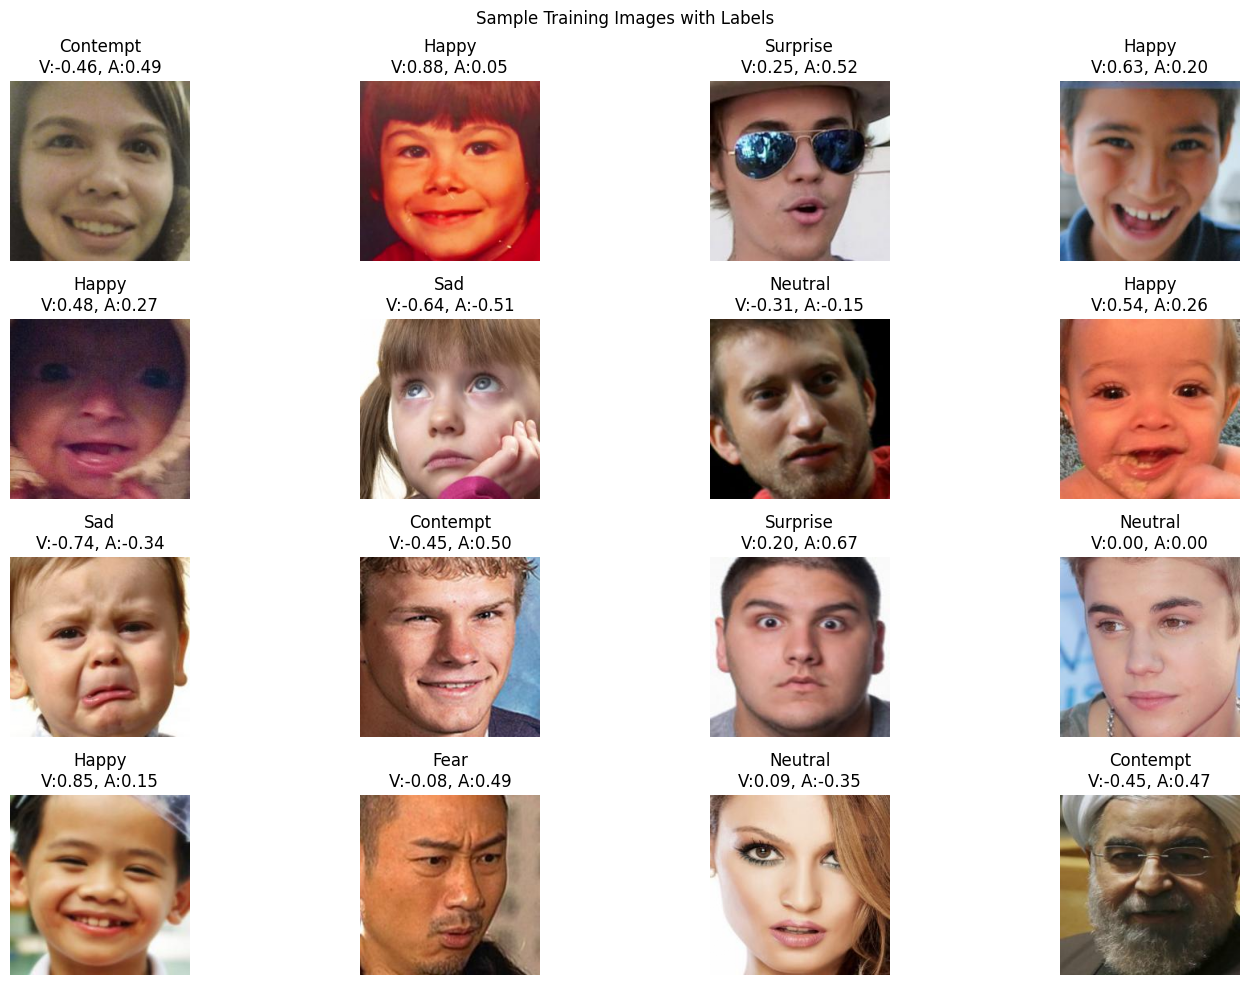

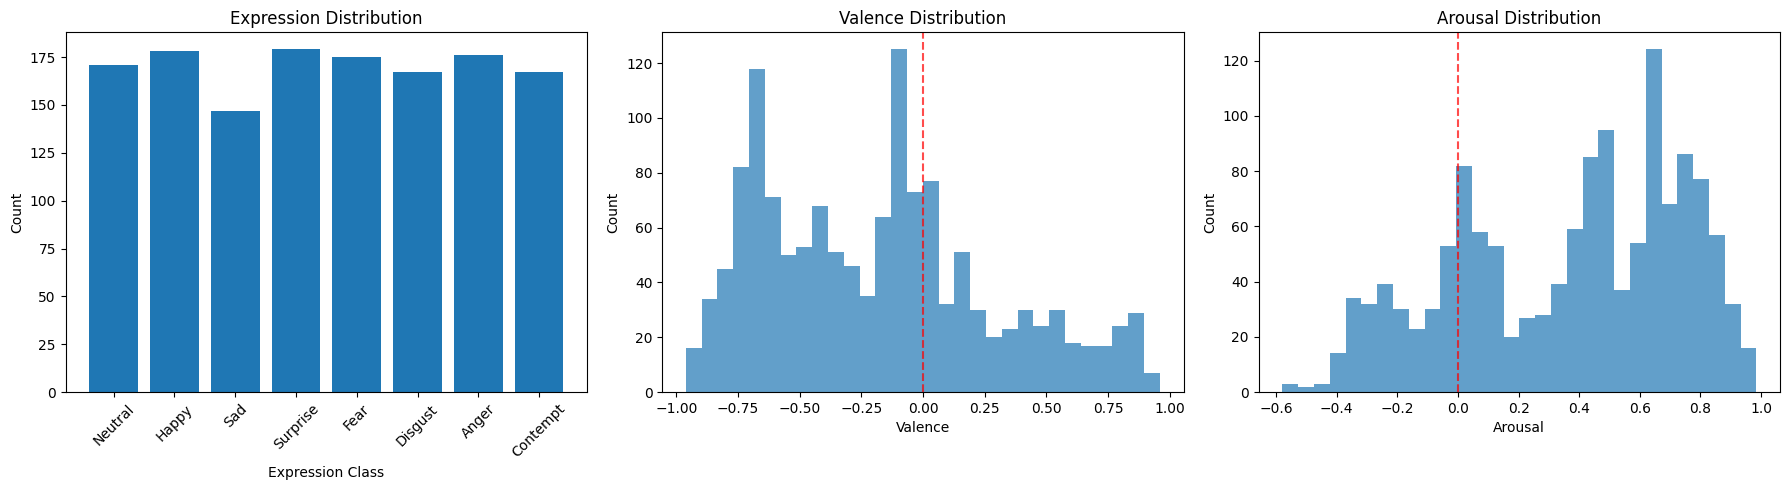

In [ ]:

# Split data into train, validation, and test sets
X_temp, X_test, y_temp_expr, y_test_expr, y_temp_val, y_test_val, y_temp_ar, y_test_ar = train_test_split(
    images, expressions, valence, arousal,
    test_size=0.15, random_state=42, stratify=expressions
)

X_train, X_val, y_train_expr, y_val_expr, y_train_val, y_val_val, y_train_ar, y_val_ar = train_test_split(
    X_temp, y_temp_expr, y_temp_val, y_temp_ar,
    test_size=0.2, random_state=42, stratify=y_temp_expr
)

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")

# Visualize sample images
emotion_classes = ['Neutral', 'Happy', 'Sad', 'Surprise', 'Fear', 'Disgust', 'Anger', 'Contempt']

plt.figure(figsize=(15, 10))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(X_train[i])
    plt.title(f'{emotion_classes[y_train_expr[i]]}\nV:{y_train_val[i]:.2f}, A:{y_train_ar[i]:.2f}')
    plt.axis('off')
plt.suptitle('Sample Training Images with Labels')
plt.tight_layout()
plt.show()

# Visualize data distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Expression distribution
expr_counts = np.bincount(y_train_expr)
axes[0].bar(range(len(expr_counts)), expr_counts)
axes[0].set_xlabel('Expression Class')
axes[0].set_ylabel('Count')
axes[0].set_title('Expression Distribution')
axes[0].set_xticks(range(len(emotion_classes)))
axes[0].set_xticklabels(emotion_classes, rotation=45)

# Valence distribution
axes[1].hist(y_train_val, bins=30, alpha=0.7)
axes[1].set_xlabel('Valence')
axes[1].set_ylabel('Count')
axes[1].set_title('Valence Distribution')
axes[1].axvline(0, color='red', linestyle='--', alpha=0.7)

# Arousal distribution
axes[2].hist(y_train_ar, bins=30, alpha=0.7)
axes[2].set_xlabel('Arousal')
axes[2].set_ylabel('Count')
axes[2].set_title('Arousal Distribution')
axes[2].axvline(0, color='red', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [ ]:

class CNNArchitectures:
    """Class containing different CNN architectures - FIXED VERSION"""

    @staticmethod
    def create_vgg16_model(input_shape=(224, 224, 3), num_classes=8):
        """Create VGG16-based model - FIXED"""
        # Create input layer
        inputs = layers.Input(shape=input_shape)

        # Load pre-trained VGG16
        base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
        base_model.trainable = False

        # Pass input through base model
        x = base_model(inputs)

        # Add custom layers
        x = layers.GlobalAveragePooling2D()(x)
        x = layers.Dense(512, activation='relu')(x)
        x = layers.Dropout(0.5)(x)
        x = layers.Dense(256, activation='relu')(x)
        x = layers.Dropout(0.3)(x)

        # Multi-output layers
        expression_output = layers.Dense(num_classes, activation='softmax', name='expression')(x)
        valence_output = layers.Dense(1, activation='tanh', name='valence')(x)
        arousal_output = layers.Dense(1, activation='tanh', name='arousal')(x)

        # Create model
        model = models.Model(inputs=inputs,
                           outputs=[expression_output, valence_output, arousal_output])

        return model

    @staticmethod
    def create_resnet50_model(input_shape=(224, 224, 3), num_classes=8):
        """Create ResNet50-based model - FIXED"""
        # Create input layer
        inputs = layers.Input(shape=input_shape)

        # Load pre-trained ResNet50
        base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
        base_model.trainable = False

        # Pass input through base model
        x = base_model(inputs)

        # Add custom layers
        x = layers.GlobalAveragePooling2D()(x)
        x = layers.Dense(512, activation='relu')(x)
        x = layers.Dropout(0.5)(x)
        x = layers.Dense(256, activation='relu')(x)
        x = layers.Dropout(0.3)(x)

        # Multi-output layers
        expression_output = layers.Dense(num_classes, activation='softmax', name='expression')(x)
        valence_output = layers.Dense(1, activation='tanh', name='valence')(x)
        arousal_output = layers.Dense(1, activation='tanh', name='arousal')(x)

        # Create model
        model = models.Model(inputs=inputs,
                           outputs=[expression_output, valence_output, arousal_output])

        return model

    @staticmethod
    def create_efficientnet_model(input_shape=(224, 224, 3), num_classes=8):
        """Create EfficientNetB0-based model - FIXED"""
        # Create input layer
        inputs = layers.Input(shape=input_shape)

        # Load pre-trained EfficientNet
        base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=input_shape)
        base_model.trainable = False

        # Pass input through base model
        x = base_model(inputs)

        # Add custom layers
        x = layers.GlobalAveragePooling2D()(x)
        x = layers.Dense(512, activation='relu')(x)
        x = layers.Dropout(0.5)(x)
        x = layers.Dense(256, activation='relu')(x)
        x = layers.Dropout(0.3)(x)

        # Multi-output layers
        expression_output = layers.Dense(num_classes, activation='softmax', name='expression')(x)
        valence_output = layers.Dense(1, activation='tanh', name='valence')(x)
        arousal_output = layers.Dense(1, activation='tanh', name='arousal')(x)

        # Create model
        model = models.Model(inputs=inputs,
                           outputs=[expression_output, valence_output, arousal_output])

        return model

    @staticmethod
    def create_custom_cnn_model(input_shape=(224, 224, 3), num_classes=8):
        """Create custom CNN architecture for extra credit - FIXED"""
        inputs = layers.Input(shape=input_shape)

        # First block
        x = layers.Conv2D(64, 3, padding='same', activation='relu')(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
        x = layers.MaxPooling2D(2)(x)
        x = layers.Dropout(0.25)(x)

        # Second block
        x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
        x = layers.MaxPooling2D(2)(x)
        x = layers.Dropout(0.25)(x)

        # Third block with residual connection
        residual = layers.Conv2D(256, 1, padding='same')(x)
        x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
        x = layers.Add()([x, residual])
        x = layers.Activation('relu')(x)
        x = layers.MaxPooling2D(2)(x)
        x = layers.Dropout(0.25)(x)

        # Fourth block
        x = layers.Conv2D(512, 3, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(512, 3, padding='same', activation='relu')(x)
        x = layers.GlobalAveragePooling2D()(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.5)(x)

        # Dense layers
        x = layers.Dense(512, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.5)(x)
        x = layers.Dense(256, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.3)(x)

        # Output layers
        expression_output = layers.Dense(num_classes, activation='softmax', name='expression')(x)
        valence_output = layers.Dense(1, activation='tanh', name='valence')(x)
        arousal_output = layers.Dense(1, activation='tanh', name='arousal')(x)

        model = models.Model(inputs=inputs,
                           outputs=[expression_output, valence_output, arousal_output])

        return model

print("Fixed model architectures defined successfully!")


Fixed model architectures defined successfully!


In [ ]:

# Data augmentation
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    brightness_range=[0.8, 1.2],
    channel_shift_range=0.1
)

# No augmentation for validation data
val_datagen = ImageDataGenerator()

print("Data augmentation pipeline created!")


Data augmentation pipeline created!


In [ ]:

def compile_model(model, learning_rate=0.001):
    """Compile model with appropriate losses and metrics"""
    optimizer = optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss={
            'expression': 'categorical_crossentropy',
            'valence': 'mse',
            'arousal': 'mse'
        },
        loss_weights={
            'expression': 1.0,
            'valence': 0.5,
            'arousal': 0.5
        },
        metrics={
            'expression': ['accuracy'],
            'valence': ['mae'],
            'arousal': ['mae']
        }
    )
    return model

def create_callbacks(model_name):
    """Create training callbacks"""
    return [
        callbacks.EarlyStopping(patience=10, restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-7, verbose=1),
        callbacks.ModelCheckpoint(
            f'best_{model_name}.h5',
            save_best_only=True,
            monitor='val_loss',
            verbose=1
        )
    ]

def compute_metrics(y_true_expr, y_pred_expr, y_true_val, y_pred_val, y_true_ar, y_pred_ar):
    """Compute all evaluation metrics"""
    from scipy.stats import pearsonr

    # Categorical metrics
    acc = accuracy_score(y_true_expr, y_pred_expr)
    f1 = f1_score(y_true_expr, y_pred_expr, average='macro')
    kappa = cohen_kappa_score(y_true_expr, y_pred_expr)

    # Valence metrics
    val_rmse = np.sqrt(np.mean((y_true_val - y_pred_val) ** 2))
    val_corr, _ = pearsonr(y_true_val.flatten(), y_pred_val.flatten())
    val_corr = val_corr if not np.isnan(val_corr) else 0.0
    val_sagr = np.mean(np.sign(y_true_val) == np.sign(y_pred_val))

    # Arousal metrics
    ar_rmse = np.sqrt(np.mean((y_true_ar - y_pred_ar) ** 2))
    ar_corr, _ = pearsonr(y_true_ar.flatten(), y_pred_ar.flatten())
    ar_corr = ar_corr if not np.isnan(ar_corr) else 0.0
    ar_sagr = np.mean(np.sign(y_true_ar) == np.sign(y_pred_ar))

    # CCC calculation
    def ccc(y_true, y_pred):
        mean_true = np.mean(y_true)
        mean_pred = np.mean(y_pred)
        var_true = np.var(y_true)
        var_pred = np.var(y_pred)
        corr_coef, _ = pearsonr(y_true.flatten(), y_pred.flatten())
        if np.isnan(corr_coef):
            corr_coef = 0.0

        numerator = 2 * corr_coef * np.sqrt(var_true) * np.sqrt(var_pred)
        denominator = var_true + var_pred + (mean_true - mean_pred) ** 2

        return numerator / denominator if denominator != 0 else 0.0

    val_ccc = ccc(y_true_val, y_pred_val)
    ar_ccc = ccc(y_true_ar, y_pred_ar)

    return {
        'expression': {'accuracy': acc, 'f1_score': f1, 'cohen_kappa': kappa},
        'valence': {'rmse': val_rmse, 'correlation': val_corr, 'sagr': val_sagr, 'ccc': val_ccc},
        'arousal': {'rmse': ar_rmse, 'correlation': ar_corr, 'sagr': ar_sagr, 'ccc': ar_ccc}
    }

print("Training utilities defined!")


Training utilities defined!


In [ ]:
print("=" * 60)
print("TRAINING VGG16 MODEL - FIXED VERSION")
print("=" * 60)

# Create and compile VGG16 model
vgg_model = CNNArchitectures.create_vgg16_model()
vgg_model = compile_model(vgg_model)

print(f"VGG16 Total parameters: {vgg_model.count_params():,}")

# Prepare data - FIXED: Properly structure multi-output labels
y_train_expr_cat = to_categorical(y_train_expr, num_classes=8)
y_val_expr_cat = to_categorical(y_val_expr, num_classes=8)

# Create the multi-output dictionary for training data
train_labels = {
    'expression': y_train_expr_cat,
    'valence': y_train_val,
    'arousal': y_train_ar
}

val_labels = {
    'expression': y_val_expr_cat,
    'valence': y_val_val,
    'arousal': y_val_ar
}

# OPTION 1: Use fit() without data generator (Recommended)
print("\nStarting VGG16 training (without data augmentation)...")
vgg_history = vgg_model.fit(
    X_train, train_labels,
    batch_size=32,
    epochs=25,
    validation_data=(X_val, val_labels),
    callbacks=create_callbacks('VGG16'),
    verbose=1
)

# OPTION 2: If you want data augmentation, use this alternative approach
def train_with_augmentation(model, X_train, train_labels, X_val, val_labels, model_name):
    """Train model with data augmentation using custom generator"""

    # Create custom data generator for multi-output
    def custom_data_generator(X, y_dict, batch_size, datagen):
        """Custom generator for multi-output with augmentation"""
        n_samples = len(X)
        indices = np.arange(n_samples)

        while True:
            # Shuffle indices for each epoch
            np.random.shuffle(indices)

            for start_idx in range(0, n_samples, batch_size):
                end_idx = min(start_idx + batch_size, n_samples)
                batch_indices = indices[start_idx:end_idx]

                # Get batch data
                batch_X = X[batch_indices]
                batch_y = {key: val[batch_indices] for key, val in y_dict.items()}

                # Apply augmentation to images
                augmented_X = np.zeros_like(batch_X)
                for i, img in enumerate(batch_X):
                    # Apply random transformations
                    img_transformed = datagen.random_transform(img)
                    img_standardized = datagen.standardize(img_transformed)
                    augmented_X[i] = img_standardized

                yield augmented_X, batch_y

    # Create the generator
    train_generator = custom_data_generator(X_train, train_labels, 32, train_datagen)

    # Train the model
    history = model.fit(
        train_generator,
        steps_per_epoch=len(X_train) // 32,
        epochs=15,
        validation_data=(X_val, val_labels),
        callbacks=create_callbacks(model_name),
        verbose=1
    )

    return history

# UNCOMMENT THIS IF YOU WANT TO USE DATA AUGMENTATION:
# print("\nStarting VGG16 training (with data augmentation)...")
# vgg_history = train_with_augmentation(vgg_model, X_train, train_labels, X_val, val_labels, 'VGG16')

print("VGG16 training completed!")

TRAINING VGG16 MODEL - FIXED VERSION
VGG16 Total parameters: 15,111,242

Starting VGG16 training (without data augmentation)...
Epoch 1/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - arousal_loss: 0.2871 - arousal_mae: 0.4354 - expression_accuracy: 0.1206 - expression_loss: 2.2013 - loss: 2.5462 - valence_loss: 0.4025 - valence_mae: 0.5092
Epoch 1: val_loss improved from inf to 2.27021, saving model to best_VGG16.h5


43/43 ━━━━━━━━━━━━━━━━━━━━ 48s 709ms/step - arousal_loss: 0.2857 - arousal_mae: 0.4343 - expression_accuracy: 0.1207 - expression_loss: 2.2001 - loss: 2.5434 - valence_loss: 0.4008 - valence_mae: 0.5081 - val_arousal_loss: 0.1549 - val_arousal_mae: 0.3483 - val_expression_accuracy: 0.1324 - val_expression_loss: 2.0740 - val_loss: 2.2702 - val_valence_loss: 0.2394 - val_valence_mae: 0.4042 - learning_rate: 0.0010
Epoch 2/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - arousal_loss: 0.1534 - arousal_mae: 0.3316 - expression_accuracy: 0.1525 - expression_loss: 2.0677 - loss: 2.2656 - valence_loss: 0.2424 - valence_mae: 0.4015
Epoch 2: val_loss improved from 2.27021 to 2.23821, saving model to best_VGG16.h5


43/43 ━━━━━━━━━━━━━━━━━━━━ 9s 210ms/step - arousal_loss: 0.1534 - arousal_mae: 0.3316 - expression_accuracy: 0.1527 - expression_loss: 2.0678 - loss: 2.2655 - valence_loss: 0.2421 - valence_mae: 0.4013 - val_arousal_loss: 0.1551 - val_arousal_mae: 0.3499 - val_expression_accuracy: 0.1794 - val_expression_loss: 2.0569 - val_loss: 2.2382 - val_valence_loss: 0.2073 - val_valence_mae: 0.3720 - learning_rate: 0.0010
Epoch 3/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - arousal_loss: 0.1490 - arousal_mae: 0.3226 - expression_accuracy: 0.1821 - expression_loss: 2.0498 - loss: 2.2409 - valence_loss: 0.2331 - valence_mae: 0.3964
Epoch 3: val_loss improved from 2.23821 to 2.22005, saving model to best_VGG16.h5


43/43 ━━━━━━━━━━━━━━━━━━━━ 10s 210ms/step - arousal_loss: 0.1490 - arousal_mae: 0.3226 - expression_accuracy: 0.1820 - expression_loss: 2.0499 - loss: 2.2408 - valence_loss: 0.2329 - valence_mae: 0.3962 - val_arousal_loss: 0.1475 - val_arousal_mae: 0.3392 - val_expression_accuracy: 0.2265 - val_expression_loss: 2.0360 - val_loss: 2.2200 - val_valence_loss: 0.2206 - val_valence_mae: 0.3865 - learning_rate: 0.0010
Epoch 4/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - arousal_loss: 0.1446 - arousal_mae: 0.3155 - expression_accuracy: 0.1961 - expression_loss: 2.0239 - loss: 2.2099 - valence_loss: 0.2274 - valence_mae: 0.3891
Epoch 4: val_loss improved from 2.22005 to 2.20336, saving model to best_VGG16.h5


43/43 ━━━━━━━━━━━━━━━━━━━━ 9s 210ms/step - arousal_loss: 0.1446 - arousal_mae: 0.3156 - expression_accuracy: 0.1961 - expression_loss: 2.0240 - loss: 2.2100 - valence_loss: 0.2273 - valence_mae: 0.3891 - val_arousal_loss: 0.1501 - val_arousal_mae: 0.3402 - val_expression_accuracy: 0.1912 - val_expression_loss: 2.0208 - val_loss: 2.2034 - val_valence_loss: 0.2145 - val_valence_mae: 0.3809 - learning_rate: 0.0010
Epoch 5/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - arousal_loss: 0.1445 - arousal_mae: 0.3187 - expression_accuracy: 0.1893 - expression_loss: 2.0126 - loss: 2.1977 - valence_loss: 0.2257 - valence_mae: 0.3915
Epoch 5: val_loss improved from 2.20336 to 2.16914, saving model to best_VGG16.h5


...

43/43 ━━━━━━━━━━━━━━━━━━━━ 9s 209ms/step - arousal_loss: 0.1339 - arousal_mae: 0.3045 - expression_accuracy: 0.2948 - expression_loss: 1.8399 - loss: 2.0121 - valence_loss: 0.2104 - valence_mae: 0.3774 - val_arousal_loss: 0.1446 - val_arousal_mae: 0.3302 - val_expression_accuracy: 0.2471 - val_expression_loss: 1.9078 - val_loss: 2.0758 - val_valence_loss: 0.1958 - val_valence_mae: 0.3626 - learning_rate: 0.0010
Epoch 13/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - arousal_loss: 0.1327 - arousal_mae: 0.3086 - expression_accuracy: 0.2847 - expression_loss: 1.8545 - loss: 2.0267 - valence_loss: 0.2116 - valence_mae: 0.3751
Epoch 13: val_loss did not improve from 2.07583
43/43 ━━━━━━━━━━━━━━━━━━━━ 9s 207ms/step - arousal_loss: 0.1327 - arousal_mae: 0.3086 - expression_accuracy: 0.2850 - expression_loss: 1.8543 - loss: 2.0265 - valence_loss: 0.2115 - valence_mae: 0.3750 - val_arousal_loss: 0.1412 - val_arousal_mae: 0.3207 - val_expression_accuracy: 0.2500 - val_expression_loss: 1.9161 - va

43/43 ━━━━━━━━━━━━━━━━━━━━ 9s 211ms/step - arousal_loss: 0.1344 - arousal_mae: 0.3066 - expression_accuracy: 0.3241 - expression_loss: 1.7988 - loss: 1.9659 - valence_loss: 0.1995 - valence_mae: 0.3646 - val_arousal_loss: 0.1401 - val_arousal_mae: 0.3236 - val_expression_accuracy: 0.2471 - val_expression_loss: 1.9022 - val_loss: 2.0673 - val_valence_loss: 0.1954 - val_valence_mae: 0.3618 - learning_rate: 0.0010
Epoch 15/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - arousal_loss: 0.1290 - arousal_mae: 0.2999 - expression_accuracy: 0.3030 - expression_loss: 1.7938 - loss: 1.9571 - valence_loss: 0.1977 - valence_mae: 0.3658
Epoch 15: val_loss did not improve from 2.06734
43/43 ━━━━━━━━━━━━━━━━━━━━ 9s 206ms/step - arousal_loss: 0.1290 - arousal_mae: 0.3001 - expression_accuracy: 0.3027 - expression_loss: 1.7941 - loss: 1.9576 - valence_loss: 0.1978 - valence_mae: 0.3658 - val_arousal_loss: 0.1417 - val_arousal_mae: 0.3274 - val_expression_accuracy: 0.2412 - val_expression_loss: 1.9294 - va

43/43 ━━━━━━━━━━━━━━━━━━━━ 9s 213ms/step - arousal_loss: 0.1301 - arousal_mae: 0.3022 - expression_accuracy: 0.3226 - expression_loss: 1.8013 - loss: 1.9658 - valence_loss: 0.1989 - valence_mae: 0.3655 - val_arousal_loss: 0.1408 - val_arousal_mae: 0.3182 - val_expression_accuracy: 0.2588 - val_expression_loss: 1.9005 - val_loss: 2.0656 - val_valence_loss: 0.1950 - val_valence_mae: 0.3609 - learning_rate: 0.0010
Epoch 17/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - arousal_loss: 0.1282 - arousal_mae: 0.2959 - expression_accuracy: 0.3277 - expression_loss: 1.7779 - loss: 1.9379 - valence_loss: 0.1918 - valence_mae: 0.3614
Epoch 17: val_loss improved from 2.06557 to 2.05738, saving model to best_VGG16.h5


43/43 ━━━━━━━━━━━━━━━━━━━━ 9s 212ms/step - arousal_loss: 0.1282 - arousal_mae: 0.2961 - expression_accuracy: 0.3278 - expression_loss: 1.7783 - loss: 1.9383 - valence_loss: 0.1918 - valence_mae: 0.3613 - val_arousal_loss: 0.1429 - val_arousal_mae: 0.3278 - val_expression_accuracy: 0.2735 - val_expression_loss: 1.8916 - val_loss: 2.0574 - val_valence_loss: 0.1936 - val_valence_mae: 0.3605 - learning_rate: 0.0010
Epoch 18/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - arousal_loss: 0.1267 - arousal_mae: 0.2978 - expression_accuracy: 0.3325 - expression_loss: 1.7749 - loss: 1.9369 - valence_loss: 0.1973 - valence_mae: 0.3630
Epoch 18: val_loss did not improve from 2.05738
43/43 ━━━━━━━━━━━━━━━━━━━━ 9s 206ms/step - arousal_loss: 0.1267 - arousal_mae: 0.2978 - expression_accuracy: 0.3325 - expression_loss: 1.7747 - loss: 1.9368 - valence_loss: 0.1972 - valence_mae: 0.3629 - val_arousal_loss: 0.1416 - val_arousal_mae: 0.3227 - val_expression_accuracy: 0.2735 - val_expression_loss: 1.9165 - va

43/43 ━━━━━━━━━━━━━━━━━━━━ 9s 212ms/step - arousal_loss: 0.1227 - arousal_mae: 0.2928 - expression_accuracy: 0.3786 - expression_loss: 1.6896 - loss: 1.8374 - valence_loss: 0.1728 - valence_mae: 0.3368 - val_arousal_loss: 0.1405 - val_arousal_mae: 0.3239 - val_expression_accuracy: 0.2912 - val_expression_loss: 1.8759 - val_loss: 2.0420 - val_valence_loss: 0.1946 - val_valence_mae: 0.3553 - learning_rate: 5.0000e-04
Epoch 24/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - arousal_loss: 0.1249 - arousal_mae: 0.2943 - expression_accuracy: 0.3792 - expression_loss: 1.6968 - loss: 1.8519 - valence_loss: 0.1852 - valence_mae: 0.3489
Epoch 24: val_loss did not improve from 2.04199
43/43 ━━━━━━━━━━━━━━━━━━━━ 9s 208ms/step - arousal_loss: 0.1249 - arousal_mae: 0.2944 - expression_accuracy: 0.3793 - expression_loss: 1.6969 - loss: 1.8520 - valence_loss: 0.1850 - valence_mae: 0.3487 - val_arousal_loss: 0.1410 - val_arousal_mae: 0.3246 - val_expression_accuracy: 0.2941 - val_expression_loss: 1.8829 

In [ ]:

print("=" * 60)
print("TRAINING RESNET50 MODEL - FIXED VERSION")
print("=" * 60)

# Create and compile ResNet50 model
resnet_model = CNNArchitectures.create_resnet50_model()
resnet_model = compile_model(resnet_model)

print(f"ResNet50 Total parameters: {resnet_model.count_params():,}")

# Train model
print("\nStarting ResNet50 training...")
resnet_history = resnet_model.fit(
    X_train, train_labels,
    batch_size=32,
    epochs=25,
    validation_data=(X_val, val_labels),
    callbacks=create_callbacks('ResNet50'),
    verbose=1
)

print("ResNet50 training completed!")


TRAINING RESNET50 MODEL - FIXED VERSION
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
ResNet50 Total parameters: 24,770,698

Starting ResNet50 training...
Epoch 1/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - arousal_loss: 0.4106 - arousal_mae: 0.5242 - expression_accuracy: 0.1157 - expression_loss: 2.3027 - loss: 2.6992 - valence_loss: 0.3824 - valence_mae: 0.4891
Epoch 1: val_loss improved from inf to 2.27803, saving model to best_ResNet50.h5


43/43 ━━━━━━━━━━━━━━━━━━━━ 36s 484ms/step - arousal_loss: 0.4079 - arousal_mae: 0.5222 - expression_accuracy: 0.1159 - expression_loss: 2.3002 - loss: 2.6947 - valence_loss: 0.3811 - valence_mae: 0.4883 - val_arousal_loss: 0.1593 - val_arousal_mae: 0.3536 - val_expression_accuracy: 0.1265 - val_expression_loss: 2.0806 - val_loss: 2.2780 - val_valence_loss: 0.2371 - val_valence_mae: 0.4005 - learning_rate: 0.0010
Epoch 2/25
42/43 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - arousal_loss: 0.1452 - arousal_mae: 0.3226 - expression_accuracy: 0.1245 - expression_loss: 2.0894 - loss: 2.2845 - valence_loss: 0.2449 - valence_mae: 0.4026
Epoch 2: val_loss improved from 2.27803 to 2.26893, saving model to best_ResNet50.h5


43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 125ms/step - arousal_loss: 0.1455 - arousal_mae: 0.3232 - expression_accuracy: 0.1247 - expression_loss: 2.0894 - loss: 2.2845 - valence_loss: 0.2446 - valence_mae: 0.4023 - val_arousal_loss: 0.1623 - val_arousal_mae: 0.3572 - val_expression_accuracy: 0.1235 - val_expression_loss: 2.0800 - val_loss: 2.2689 - val_valence_loss: 0.2172 - val_valence_mae: 0.3778 - learning_rate: 0.0010
Epoch 3/25
42/43 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - arousal_loss: 0.1418 - arousal_mae: 0.3226 - expression_accuracy: 0.1289 - expression_loss: 2.0941 - loss: 2.2852 - valence_loss: 0.2405 - valence_mae: 0.4050
Epoch 3: val_loss did not improve from 2.26893
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - arousal_loss: 0.1421 - arousal_mae: 0.3230 - expression_accuracy: 0.1289 - expression_loss: 2.0938 - loss: 2.2849 - valence_loss: 0.2400 - valence_mae: 0.4046 - val_arousal_loss: 0.1676 - val_arousal_mae: 0.3630 - val_expression_accuracy: 0.1265 - val_expression_loss: 2.0806 - val_l

43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step - arousal_loss: 0.1393 - arousal_mae: 0.3214 - expression_accuracy: 0.1336 - expression_loss: 2.0828 - loss: 2.2677 - valence_loss: 0.2304 - valence_mae: 0.3932 - val_arousal_loss: 0.1656 - val_arousal_mae: 0.3609 - val_expression_accuracy: 0.1206 - val_expression_loss: 2.0779 - val_loss: 2.2673 - val_valence_loss: 0.2154 - val_valence_mae: 0.3765 - learning_rate: 0.0010
Epoch 5/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - arousal_loss: 0.1424 - arousal_mae: 0.3269 - expression_accuracy: 0.1257 - expression_loss: 2.0773 - loss: 2.2649 - valence_loss: 0.2328 - valence_mae: 0.3960
Epoch 5: val_loss improved from 2.26733 to 2.26126, saving model to best_ResNet50.h5


43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 126ms/step - arousal_loss: 0.1425 - arousal_mae: 0.3270 - expression_accuracy: 0.1256 - expression_loss: 2.0773 - loss: 2.2649 - valence_loss: 0.2326 - valence_mae: 0.3959 - val_arousal_loss: 0.1527 - val_arousal_mae: 0.3443 - val_expression_accuracy: 0.1265 - val_expression_loss: 2.0780 - val_loss: 2.2613 - val_valence_loss: 0.2149 - val_valence_mae: 0.3765 - learning_rate: 0.0010
Epoch 6/25
42/43 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - arousal_loss: 0.1368 - arousal_mae: 0.3159 - expression_accuracy: 0.1250 - expression_loss: 2.0752 - loss: 2.2564 - valence_loss: 0.2255 - valence_mae: 0.3907
Epoch 6: val_loss did not improve from 2.26126
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - arousal_loss: 0.1370 - arousal_mae: 0.3163 - expression_accuracy: 0.1250 - expression_loss: 2.0754 - loss: 2.2565 - valence_loss: 0.2252 - valence_mae: 0.3905 - val_arousal_loss: 0.1535 - val_arousal_mae: 0.3455 - val_expression_accuracy: 0.1382 - val_expression_loss: 2.0782 - val_l

...

43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 125ms/step - arousal_loss: 0.1337 - arousal_mae: 0.3133 - expression_accuracy: 0.1365 - expression_loss: 2.0733 - loss: 2.2522 - valence_loss: 0.2240 - valence_mae: 0.3877 - val_arousal_loss: 0.1501 - val_arousal_mae: 0.3337 - val_expression_accuracy: 0.1441 - val_expression_loss: 2.0745 - val_loss: 2.2561 - val_valence_loss: 0.2154 - val_valence_mae: 0.3767 - learning_rate: 0.0010
Epoch 11/25
42/43 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - arousal_loss: 0.1354 - arousal_mae: 0.3157 - expression_accuracy: 0.1172 - expression_loss: 2.0766 - loss: 2.2560 - valence_loss: 0.2234 - valence_mae: 0.3863
Epoch 11: val_loss did not improve from 2.25605
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - arousal_loss: 0.1356 - arousal_mae: 0.3160 - expression_accuracy: 0.1172 - expression_loss: 2.0767 - loss: 2.2561 - valence_loss: 0.2231 - valence_mae: 0.3862 - val_arousal_loss: 0.1505 - val_arousal_mae: 0.3377 - val_expression_accuracy: 0.1294 - val_expression_loss: 2.0783 - val

43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 130ms/step - arousal_loss: 0.1331 - arousal_mae: 0.3117 - expression_accuracy: 0.1417 - expression_loss: 2.0676 - loss: 2.2459 - valence_loss: 0.2235 - valence_mae: 0.3873 - val_arousal_loss: 0.1498 - val_arousal_mae: 0.3369 - val_expression_accuracy: 0.1235 - val_expression_loss: 2.0743 - val_loss: 2.2560 - val_valence_loss: 0.2151 - val_valence_mae: 0.3766 - learning_rate: 5.0000e-04
Epoch 21/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - arousal_loss: 0.1341 - arousal_mae: 0.3137 - expression_accuracy: 0.1358 - expression_loss: 2.0736 - loss: 2.2517 - valence_loss: 0.2223 - valence_mae: 0.3867
Epoch 21: val_loss improved from 2.25605 to 2.25419, saving model to best_ResNet50.h5


43/43 ━━━━━━━━━━━━━━━━━━━━ 10s 122ms/step - arousal_loss: 0.1341 - arousal_mae: 0.3138 - expression_accuracy: 0.1357 - expression_loss: 2.0736 - loss: 2.2517 - valence_loss: 0.2221 - valence_mae: 0.3866 - val_arousal_loss: 0.1496 - val_arousal_mae: 0.3366 - val_expression_accuracy: 0.1353 - val_expression_loss: 2.0728 - val_loss: 2.2542 - val_valence_loss: 0.2151 - val_valence_mae: 0.3767 - learning_rate: 2.5000e-04
Epoch 22/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - arousal_loss: 0.1339 - arousal_mae: 0.3134 - expression_accuracy: 0.1423 - expression_loss: 2.0662 - loss: 2.2452 - valence_loss: 0.2242 - valence_mae: 0.3873
Epoch 22: val_loss improved from 2.25419 to 2.25351, saving model to best_ResNet50.h5


43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 125ms/step - arousal_loss: 0.1339 - arousal_mae: 0.3135 - expression_accuracy: 0.1423 - expression_loss: 2.0663 - loss: 2.2452 - valence_loss: 0.2240 - valence_mae: 0.3873 - val_arousal_loss: 0.1496 - val_arousal_mae: 0.3366 - val_expression_accuracy: 0.1353 - val_expression_loss: 2.0722 - val_loss: 2.2535 - val_valence_loss: 0.2150 - val_valence_mae: 0.3766 - learning_rate: 2.5000e-04
Epoch 23/25
42/43 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - arousal_loss: 0.1343 - arousal_mae: 0.3146 - expression_accuracy: 0.1287 - expression_loss: 2.0744 - loss: 2.2530 - valence_loss: 0.2229 - valence_mae: 0.3859
Epoch 23: val_loss improved from 2.25351 to 2.25305, saving model to best_ResNet50.h5


43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - arousal_loss: 0.1344 - arousal_mae: 0.3148 - expression_accuracy: 0.1293 - expression_loss: 2.0743 - loss: 2.2528 - valence_loss: 0.2226 - valence_mae: 0.3858 - val_arousal_loss: 0.1495 - val_arousal_mae: 0.3360 - val_expression_accuracy: 0.1382 - val_expression_loss: 2.0718 - val_loss: 2.2530 - val_valence_loss: 0.2150 - val_valence_mae: 0.3765 - learning_rate: 2.5000e-04
Epoch 24/25
42/43 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - arousal_loss: 0.1354 - arousal_mae: 0.3138 - expression_accuracy: 0.1394 - expression_loss: 2.0740 - loss: 2.2537 - valence_loss: 0.2238 - valence_mae: 0.3875
Epoch 24: val_loss did not improve from 2.25305
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - arousal_loss: 0.1355 - arousal_mae: 0.3140 - expression_accuracy: 0.1392 - expression_loss: 2.0741 - loss: 2.2537 - valence_loss: 0.2235 - valence_mae: 0.3873 - val_arousal_loss: 0.1504 - val_arousal_mae: 0.3388 - val_expression_accuracy: 0.1500 - val_expression_loss: 2.0758 -

In [ ]:

print("=" * 60)
print("TRAINING EFFICIENTNET MODEL - FIXED VERSION")
print("=" * 60)

# Create and compile EfficientNet model
efficient_model = CNNArchitectures.create_efficientnet_model()
efficient_model = compile_model(efficient_model)

print(f"EfficientNet Total parameters: {efficient_model.count_params():,}")

# Train model
print("\nStarting EfficientNet training...")
efficient_history = efficient_model.fit(
    X_train, train_labels,
    batch_size=32,
    epochs=25,
    validation_data=(X_val, val_labels),
    callbacks=create_callbacks('EfficientNet'),
    verbose=1
)

print("EfficientNet training completed!")


TRAINING EFFICIENTNET MODEL - FIXED VERSION
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
EfficientNet Total parameters: 4,839,341

Starting EfficientNet training...
Epoch 1/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - arousal_loss: 0.2729 - arousal_mae: 0.4184 - expression_accuracy: 0.1108 - expression_loss: 2.1494 - loss: 2.4344 - valence_loss: 0.2970 - valence_mae: 0.4362
Epoch 1: val_loss improved from inf to 2.27280, saving model to best_EfficientNet.h5


43/43 ━━━━━━━━━━━━━━━━━━━━ 67s 901ms/step - arousal_loss: 0.2713 - arousal_mae: 0.4173 - expression_accuracy: 0.1109 - expression_loss: 2.1489 - loss: 2.4328 - valence_loss: 0.2964 - valence_mae: 0.4359 - val_arousal_loss: 0.1580 - val_arousal_mae: 0.3521 - val_expression_accuracy: 0.1324 - val_expression_loss: 2.0816 - val_loss: 2.2728 - val_valence_loss: 0.2248 - val_valence_mae: 0.3866 - learning_rate: 0.0010
Epoch 2/25
42/43 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - arousal_loss: 0.1488 - arousal_mae: 0.3290 - expression_accuracy: 0.1407 - expression_loss: 2.0912 - loss: 2.2855 - valence_loss: 0.2399 - valence_mae: 0.4033
Epoch 2: val_loss improved from 2.27280 to 2.26379, saving model to best_EfficientNet.h5


43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - arousal_loss: 0.1489 - arousal_mae: 0.3291 - expression_accuracy: 0.1404 - expression_loss: 2.0912 - loss: 2.2853 - valence_loss: 0.2395 - valence_mae: 0.4029 - val_arousal_loss: 0.1521 - val_arousal_mae: 0.3428 - val_expression_accuracy: 0.1294 - val_expression_loss: 2.0799 - val_loss: 2.2638 - val_valence_loss: 0.2175 - val_valence_mae: 0.3782 - learning_rate: 0.0010
Epoch 3/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - arousal_loss: 0.1462 - arousal_mae: 0.3263 - expression_accuracy: 0.1370 - expression_loss: 2.0812 - loss: 2.2679 - valence_loss: 0.2274 - valence_mae: 0.3919
Epoch 3: val_loss did not improve from 2.26379
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - arousal_loss: 0.1462 - arousal_mae: 0.3264 - expression_accuracy: 0.1369 - expression_loss: 2.0812 - loss: 2.2680 - valence_loss: 0.2273 - valence_mae: 0.3918 - val_arousal_loss: 0.1665 - val_arousal_mae: 0.3619 - val_expression_accuracy: 0.1265 - val_expression_loss: 2.0791 - val_los

43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - arousal_loss: 0.1428 - arousal_mae: 0.3311 - expression_accuracy: 0.1007 - expression_loss: 2.0821 - loss: 2.2661 - valence_loss: 0.2251 - valence_mae: 0.3874 - val_arousal_loss: 0.1521 - val_arousal_mae: 0.3428 - val_expression_accuracy: 0.1294 - val_expression_loss: 2.0786 - val_loss: 2.2613 - val_valence_loss: 0.2149 - val_valence_mae: 0.3765 - learning_rate: 0.0010
Epoch 7/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - arousal_loss: 0.1367 - arousal_mae: 0.3192 - expression_accuracy: 0.1533 - expression_loss: 2.0767 - loss: 2.2568 - valence_loss: 0.2235 - valence_mae: 0.3872
Epoch 7: val_loss improved from 2.26134 to 2.26051, saving model to best_EfficientNet.h5


43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - arousal_loss: 0.1368 - arousal_mae: 0.3192 - expression_accuracy: 0.1530 - expression_loss: 2.0767 - loss: 2.2568 - valence_loss: 0.2234 - valence_mae: 0.3871 - val_arousal_loss: 0.1504 - val_arousal_mae: 0.3364 - val_expression_accuracy: 0.1294 - val_expression_loss: 2.0784 - val_loss: 2.2605 - val_valence_loss: 0.2154 - val_valence_mae: 0.3772 - learning_rate: 0.0010
Epoch 8/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - arousal_loss: 0.1347 - arousal_mae: 0.3151 - expression_accuracy: 0.1240 - expression_loss: 2.0771 - loss: 2.2565 - valence_loss: 0.2241 - valence_mae: 0.3876
Epoch 8: val_loss improved from 2.26051 to 2.26025, saving model to best_EfficientNet.h5


...

43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - arousal_loss: 0.1336 - arousal_mae: 0.3144 - expression_accuracy: 0.1253 - expression_loss: 2.0775 - loss: 2.2555 - valence_loss: 0.2224 - valence_mae: 0.3861 - val_arousal_loss: 0.1505 - val_arousal_mae: 0.3373 - val_expression_accuracy: 0.1324 - val_expression_loss: 2.0782 - val_loss: 2.2602 - val_valence_loss: 0.2151 - val_valence_mae: 0.3769 - learning_rate: 5.0000e-04
Epoch 18/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - arousal_loss: 0.1349 - arousal_mae: 0.3163 - expression_accuracy: 0.1220 - expression_loss: 2.0760 - loss: 2.2549 - valence_loss: 0.2228 - valence_mae: 0.3872
Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 18: val_loss improved from 2.26017 to 2.26016, saving model to best_EfficientNet.h5


43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - arousal_loss: 0.1350 - arousal_mae: 0.3164 - expression_accuracy: 0.1218 - expression_loss: 2.0761 - loss: 2.2549 - valence_loss: 0.2227 - valence_mae: 0.3871 - val_arousal_loss: 0.1505 - val_arousal_mae: 0.3372 - val_expression_accuracy: 0.1324 - val_expression_loss: 2.0782 - val_loss: 2.2602 - val_valence_loss: 0.2151 - val_valence_mae: 0.3769 - learning_rate: 5.0000e-04
Epoch 19/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - arousal_loss: 0.1350 - arousal_mae: 0.3161 - expression_accuracy: 0.1142 - expression_loss: 2.0768 - loss: 2.2563 - valence_loss: 0.2239 - valence_mae: 0.3876
Epoch 19: val_loss improved from 2.26016 to 2.26012, saving model to best_EfficientNet.h5


43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - arousal_loss: 0.1351 - arousal_mae: 0.3162 - expression_accuracy: 0.1144 - expression_loss: 2.0769 - loss: 2.2563 - valence_loss: 0.2237 - valence_mae: 0.3876 - val_arousal_loss: 0.1505 - val_arousal_mae: 0.3373 - val_expression_accuracy: 0.1324 - val_expression_loss: 2.0782 - val_loss: 2.2601 - val_valence_loss: 0.2151 - val_valence_mae: 0.3768 - learning_rate: 2.5000e-04
Epoch 20/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - arousal_loss: 0.1338 - arousal_mae: 0.3143 - expression_accuracy: 0.1220 - expression_loss: 2.0760 - loss: 2.2547 - valence_loss: 0.2235 - valence_mae: 0.3871
Epoch 20: val_loss improved from 2.26012 to 2.26011, saving model to best_EfficientNet.h5


43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - arousal_loss: 0.1339 - arousal_mae: 0.3144 - expression_accuracy: 0.1223 - expression_loss: 2.0761 - loss: 2.2547 - valence_loss: 0.2234 - valence_mae: 0.3870 - val_arousal_loss: 0.1505 - val_arousal_mae: 0.3372 - val_expression_accuracy: 0.1324 - val_expression_loss: 2.0782 - val_loss: 2.2601 - val_valence_loss: 0.2150 - val_valence_mae: 0.3768 - learning_rate: 2.5000e-04
Epoch 21/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - arousal_loss: 0.1343 - arousal_mae: 0.3148 - expression_accuracy: 0.1179 - expression_loss: 2.0774 - loss: 2.2561 - valence_loss: 0.2231 - valence_mae: 0.3874
Epoch 21: val_loss improved from 2.26011 to 2.26010, saving model to best_EfficientNet.h5


43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - arousal_loss: 0.1344 - arousal_mae: 0.3149 - expression_accuracy: 0.1179 - expression_loss: 2.0775 - loss: 2.2561 - valence_loss: 0.2229 - valence_mae: 0.3873 - val_arousal_loss: 0.1505 - val_arousal_mae: 0.3373 - val_expression_accuracy: 0.1324 - val_expression_loss: 2.0782 - val_loss: 2.2601 - val_valence_loss: 0.2150 - val_valence_mae: 0.3768 - learning_rate: 2.5000e-04
Epoch 22/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - arousal_loss: 0.1363 - arousal_mae: 0.3169 - expression_accuracy: 0.1212 - expression_loss: 2.0766 - loss: 2.2559 - valence_loss: 0.2224 - valence_mae: 0.3868
Epoch 22: val_loss did not improve from 2.26010
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - arousal_loss: 0.1363 - arousal_mae: 0.3170 - expression_accuracy: 0.1212 - expression_loss: 2.0766 - loss: 2.2559 - valence_loss: 0.2222 - valence_mae: 0.3868 - val_arousal_loss: 0.1505 - val_arousal_mae: 0.3373 - val_expression_accuracy: 0.1324 - val_expression_loss: 2.0782 - v

In [ ]:

print("=" * 60)
print("MODEL EVALUATION")
print("=" * 60)

# Prepare test data
y_test_expr_cat = to_categorical(y_test_expr, num_classes=8)

models_dict = {
    'VGG16': vgg_model,
    'ResNet50': resnet_model,
    'EfficientNet': efficient_model
}

histories_dict = {
    'VGG16': vgg_history,
    'ResNet50': resnet_history,
    'EfficientNet': efficient_history
}

results = {}

# Evaluate each model
for model_name, model in models_dict.items():
    print(f"\nEvaluating {model_name}...")

    # Predict on test set
    predictions = model.predict(X_test, verbose=0)
    expr_pred_proba = predictions[0]
    val_pred = predictions[1].flatten()
    ar_pred = predictions[2].flatten()

    expr_pred = np.argmax(expr_pred_proba, axis=1)

    # Compute metrics
    metrics = compute_metrics(y_test_expr, expr_pred, y_test_val, val_pred, y_test_ar, ar_pred)

    results[model_name] = {
        'metrics': metrics,
        'predictions': {
            'expression': expr_pred,
            'valence': val_pred,
            'arousal': ar_pred
        }
    }

    # Print results
    print(f"{model_name} Results:")
    print("-" * 30)
    expr_metrics = metrics['expression']
    val_metrics = metrics['valence']
    ar_metrics = metrics['arousal']

    print(f"Expression Classification:")
    print(f"  Accuracy: {expr_metrics['accuracy']:.4f}")
    print(f"  F1-Score: {expr_metrics['f1_score']:.4f}")
    print(f"  Cohen's Kappa: {expr_metrics['cohen_kappa']:.4f}")

    print(f"Valence Prediction:")
    print(f"  RMSE: {val_metrics['rmse']:.4f}")
    print(f"  Correlation: {val_metrics['correlation']:.4f}")
    print(f"  SAGR: {val_metrics['sagr']:.4f}")
    print(f"  CCC: {val_metrics['ccc']:.4f}")

    print(f"Arousal Prediction:")
    print(f"  RMSE: {ar_metrics['rmse']:.4f}")
    print(f"  Correlation: {ar_metrics['correlation']:.4f}")
    print(f"  SAGR: {ar_metrics['sagr']:.4f}")
    print(f"  CCC: {ar_metrics['ccc']:.4f}")

print("\nEvaluation completed!")


MODEL EVALUATION

Evaluating VGG16...
VGG16 Results:
------------------------------
Expression Classification:
  Accuracy: 0.2800
  F1-Score: 0.2715
  Cohen's Kappa: 0.1755
Valence Prediction:
  RMSE: 0.4343
  Correlation: 0.4177
  SAGR: 0.7200
  CCC: 0.2343
Arousal Prediction:
  RMSE: 0.3655
  Correlation: 0.2658
  SAGR: 0.7833
  CCC: 0.1475

Evaluating ResNet50...
ResNet50 Results:
------------------------------
Expression Classification:
  Accuracy: 0.1367
  F1-Score: 0.0714
  Cohen's Kappa: 0.0065
Valence Prediction:
  RMSE: 0.4736
  Correlation: 0.0307
  SAGR: 0.6933
  CCC: 0.0009
Arousal Prediction:
  RMSE: 0.3735
  Correlation: 0.0121
  SAGR: 0.7833
  CCC: 0.0016

Evaluating EfficientNet...
EfficientNet Results:
------------------------------
Expression Classification:
  Accuracy: 0.1333
  F1-Score: 0.0294
  Cohen's Kappa: 0.0000
Valence Prediction:
  RMSE: 0.4737
  Correlation: 0.0000
  SAGR: 0.6933
  CCC: 0.0000
Arousal Prediction:
  RMSE: 0.3730
  Correlation: 0.0000
  SAGR: 

Plotting training histories...


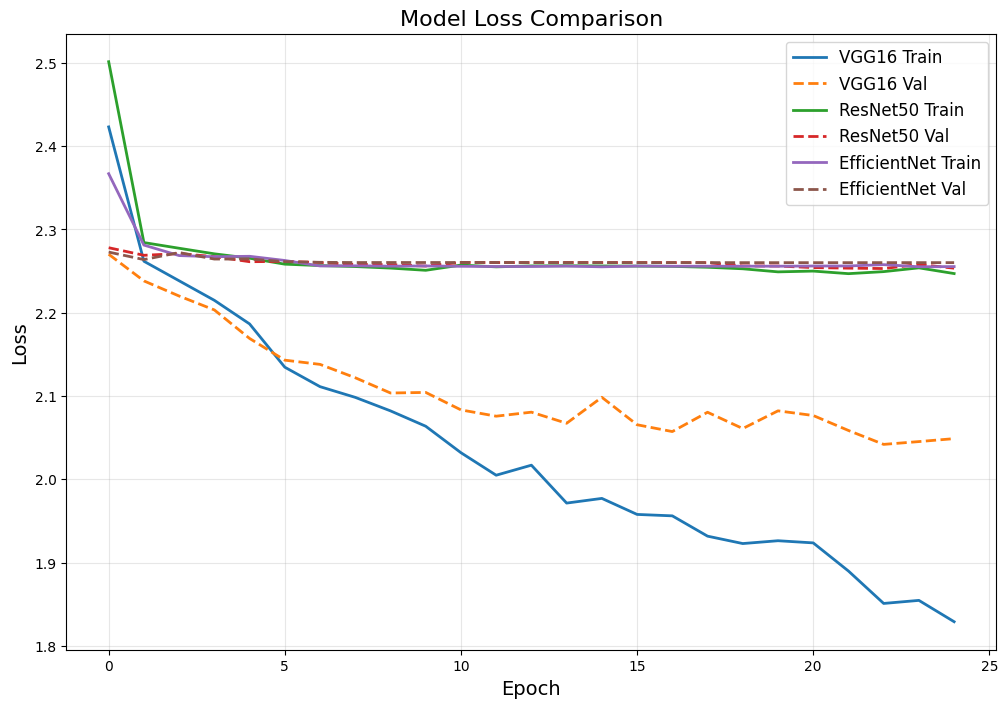

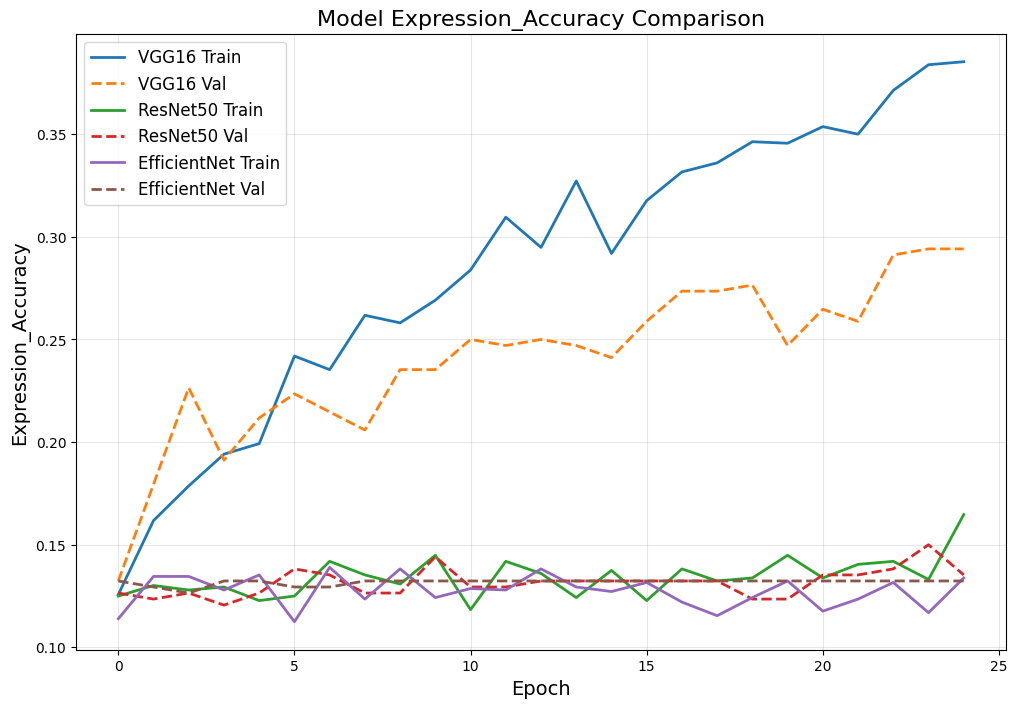

In [ ]:

# Plot training histories
def plot_training_history(histories, metric='loss'):
    plt.figure(figsize=(12, 8))

    for model_name, history in histories.items():
        plt.plot(history.history[metric], label=f'{model_name} Train', linewidth=2)
        plt.plot(history.history[f'val_{metric}'], label=f'{model_name} Val', linestyle='--', linewidth=2)

    plt.title(f'Model {metric.title()} Comparison', fontsize=16)
    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel(metric.title(), fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.show()

# Plot training curves
print("Plotting training histories...")
plot_training_history(histories_dict, 'loss')
plot_training_history(histories_dict, 'expression_accuracy')


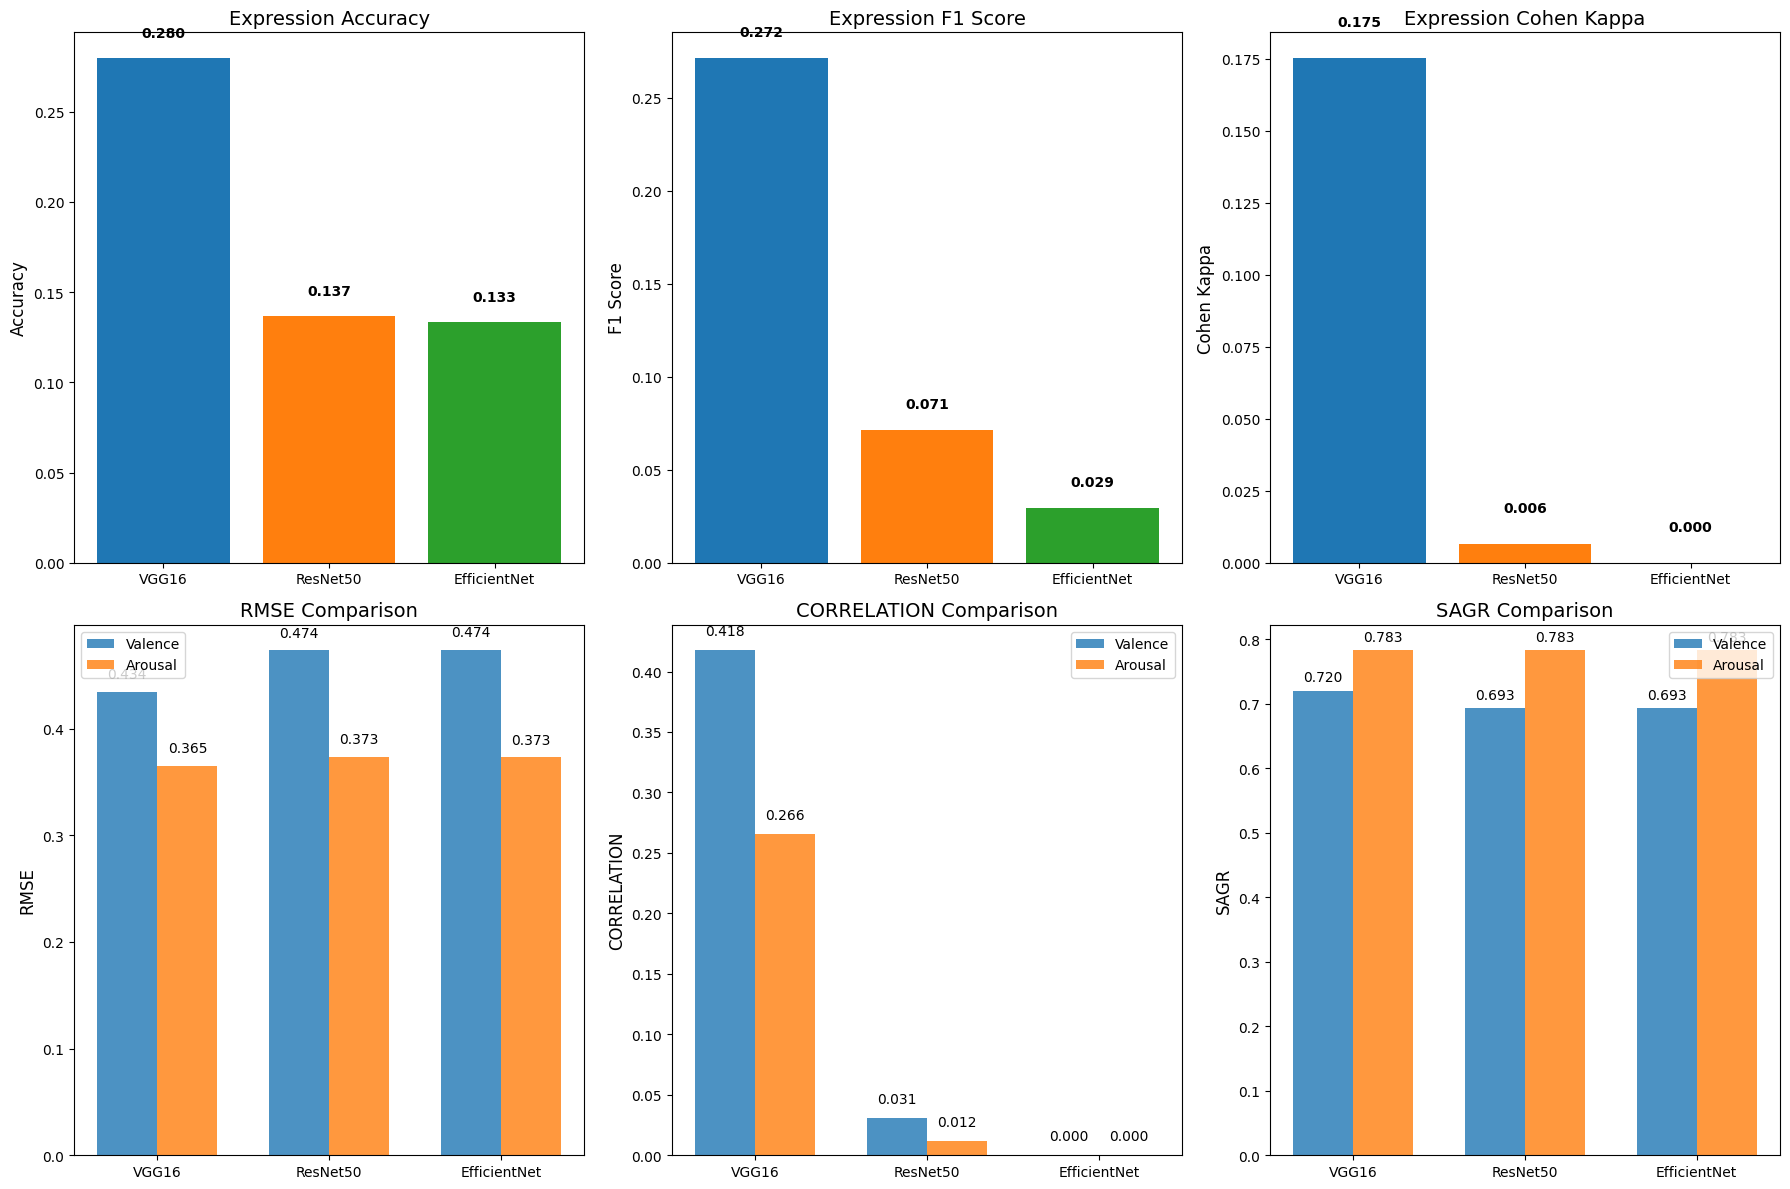

In [ ]:

# Plot results comparison
model_names = list(results.keys())

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Expression metrics
expr_metrics_names = ['accuracy', 'f1_score', 'cohen_kappa']
for i, metric in enumerate(expr_metrics_names):
    values = [results[model]['metrics']['expression'][metric] for model in model_names]
    bars = axes[0, i].bar(model_names, values, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    axes[0, i].set_title(f'Expression {metric.replace("_", " ").title()}', fontsize=14)
    axes[0, i].set_ylabel(metric.replace("_", " ").title(), fontsize=12)

    # Add value labels on bars
    for bar, value in zip(bars, values):
        axes[0, i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                       f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

# Continuous metrics
cont_metrics_names = ['rmse', 'correlation', 'sagr']
for i, metric in enumerate(cont_metrics_names):
    val_values = [results[model]['metrics']['valence'][metric] for model in model_names]
    ar_values = [results[model]['metrics']['arousal'][metric] for model in model_names]

    x = np.arange(len(model_names))
    width = 0.35

    bars1 = axes[1, i].bar(x - width/2, val_values, width, label='Valence', alpha=0.8)
    bars2 = axes[1, i].bar(x + width/2, ar_values, width, label='Arousal', alpha=0.8)

    axes[1, i].set_title(f'{metric.upper()} Comparison', fontsize=14)
    axes[1, i].set_ylabel(metric.upper(), fontsize=12)
    axes[1, i].set_xticks(x)
    axes[1, i].set_xticklabels(model_names)
    axes[1, i].legend()

    # Add value labels
    for bar, value in zip(bars1, val_values):
        axes[1, i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                       f'{value:.3f}', ha='center', va='bottom', fontsize=10)
    for bar, value in zip(bars2, ar_values):
        axes[1, i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                       f'{value:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()



Best performing model: VGG16


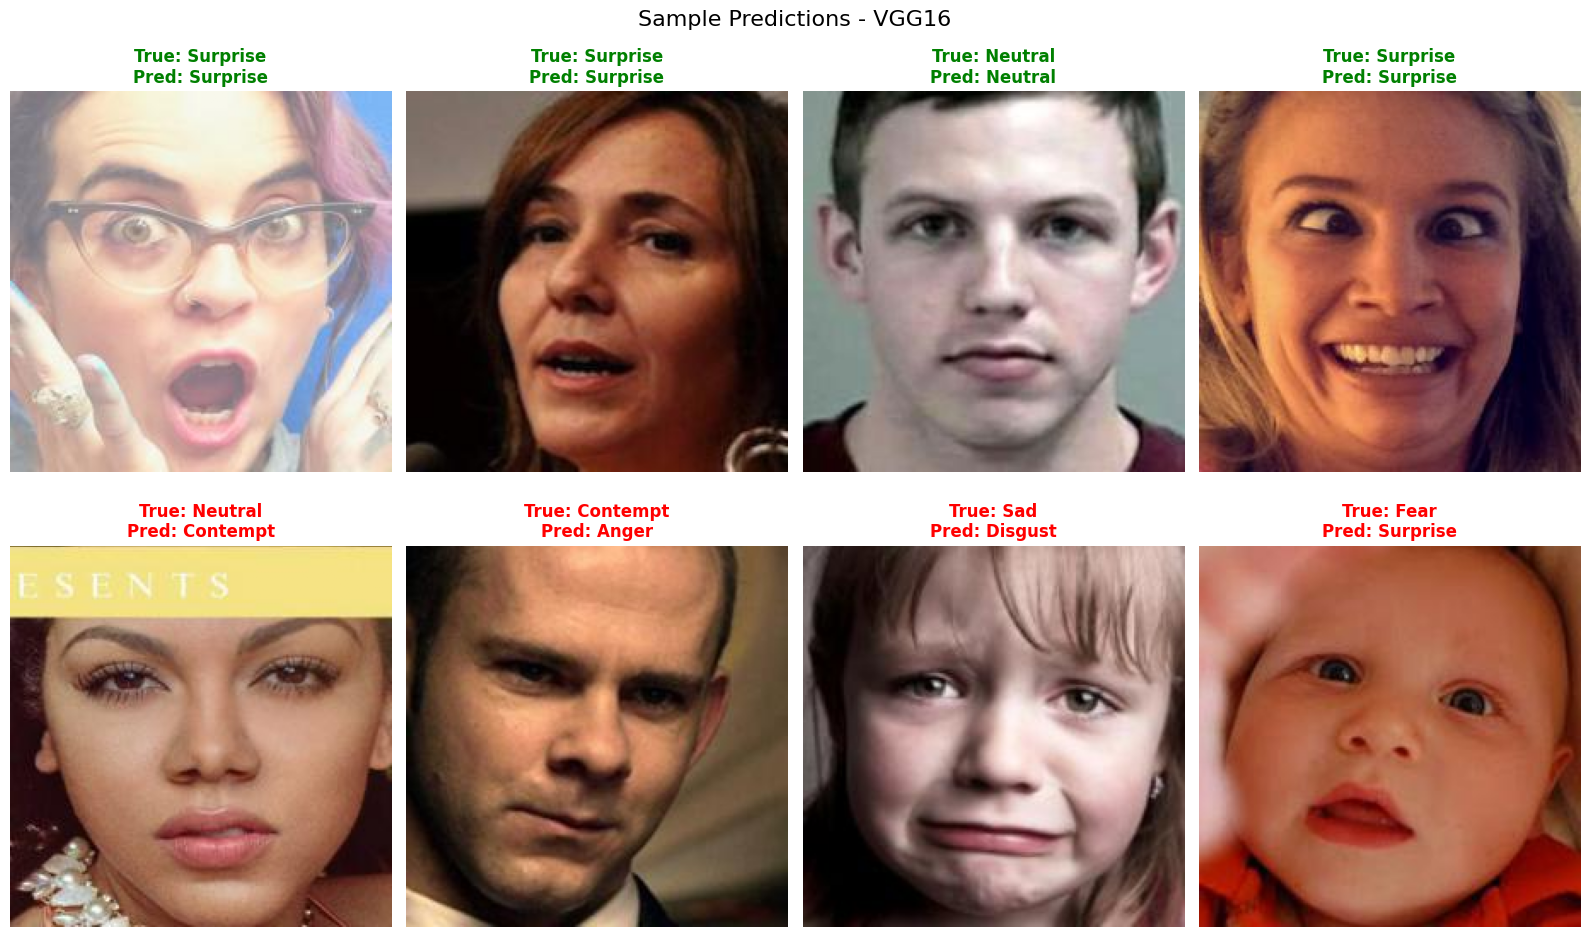

In [ ]:

# Find best model
best_model_name = max(results.keys(),
                     key=lambda x: results[x]['metrics']['expression']['accuracy'])
print(f"\nBest performing model: {best_model_name}")

# Show sample predictions
def show_sample_predictions(images, true_labels, pred_labels, class_names, num_samples=8):
    plt.figure(figsize=(16, 10))

    # Get some correct and incorrect predictions
    correct_indices = np.where(true_labels == pred_labels)[0]
    incorrect_indices = np.where(true_labels != pred_labels)[0]

    # Mix of correct and incorrect
    selected_indices = []
    if len(correct_indices) >= num_samples//2:
        selected_indices.extend(np.random.choice(correct_indices, num_samples//2, replace=False))
    if len(incorrect_indices) >= num_samples//2:
        selected_indices.extend(np.random.choice(incorrect_indices, num_samples//2, replace=False))

    # Fill remaining with random
    while len(selected_indices) < num_samples:
        idx = np.random.randint(len(images))
        if idx not in selected_indices:
            selected_indices.append(idx)

    for i, idx in enumerate(selected_indices):
        plt.subplot(2, 4, i + 1)
        plt.imshow(images[idx])

        # Color code: green for correct, red for incorrect
        color = 'green' if true_labels[idx] == pred_labels[idx] else 'red'
        plt.title(f'True: {class_names[true_labels[idx]]}\nPred: {class_names[pred_labels[idx]]}',
                 color=color, fontweight='bold')
        plt.axis('off')

    plt.suptitle(f'Sample Predictions - {best_model_name}', fontsize=16)
    plt.tight_layout()
    plt.show()

emotion_classes = ['Neutral', 'Happy', 'Sad', 'Surprise', 'Fear', 'Disgust', 'Anger', 'Contempt']
best_results = results[best_model_name]
show_sample_predictions(
    X_test, y_test_expr,
    best_results['predictions']['expression'],
    emotion_classes
)


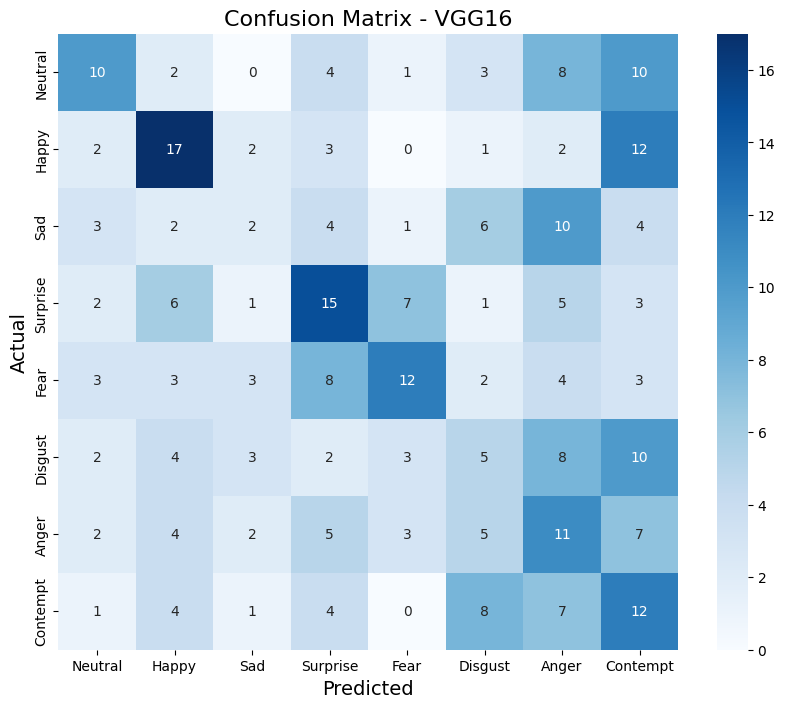

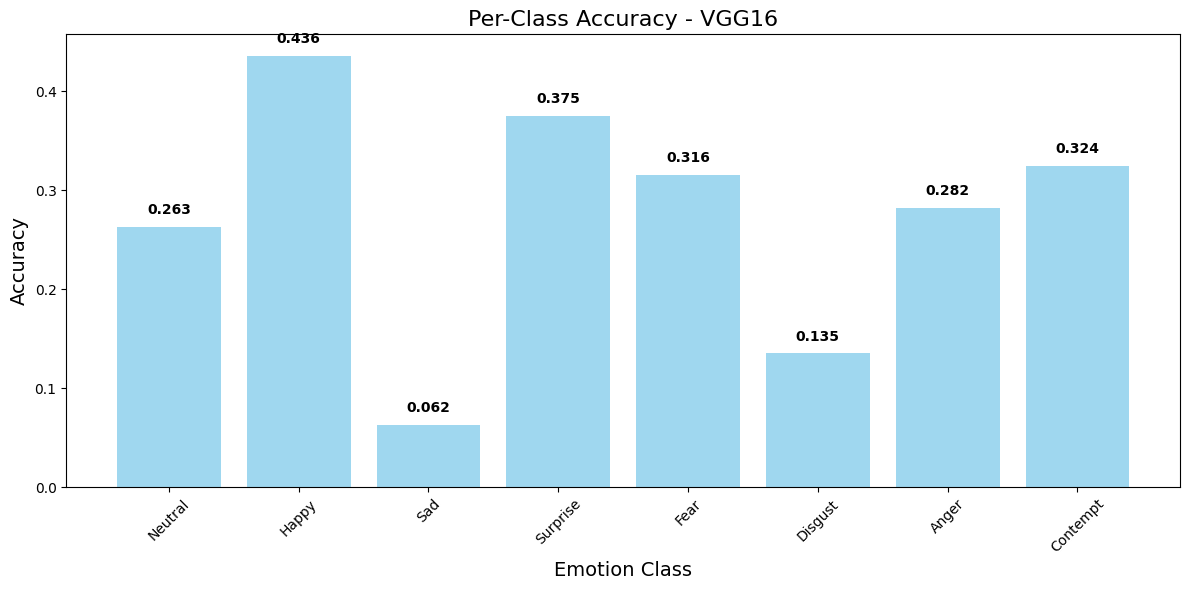

In [ ]:

# Confusion Matrix for best model
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test_expr, best_results['predictions']['expression'])

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_classes, yticklabels=emotion_classes)
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=16)
plt.xlabel('Predicted', fontsize=14)
plt.ylabel('Actual', fontsize=14)
plt.show()

# Per-class accuracy
class_accuracies = cm.diagonal() / cm.sum(axis=1)
plt.figure(figsize=(12, 6))
bars = plt.bar(emotion_classes, class_accuracies, color='skyblue', alpha=0.8)
plt.title(f'Per-Class Accuracy - {best_model_name}', fontsize=16)
plt.ylabel('Accuracy', fontsize=14)
plt.xlabel('Emotion Class', fontsize=14)
plt.xticks(rotation=45)

for bar, acc in zip(bars, class_accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


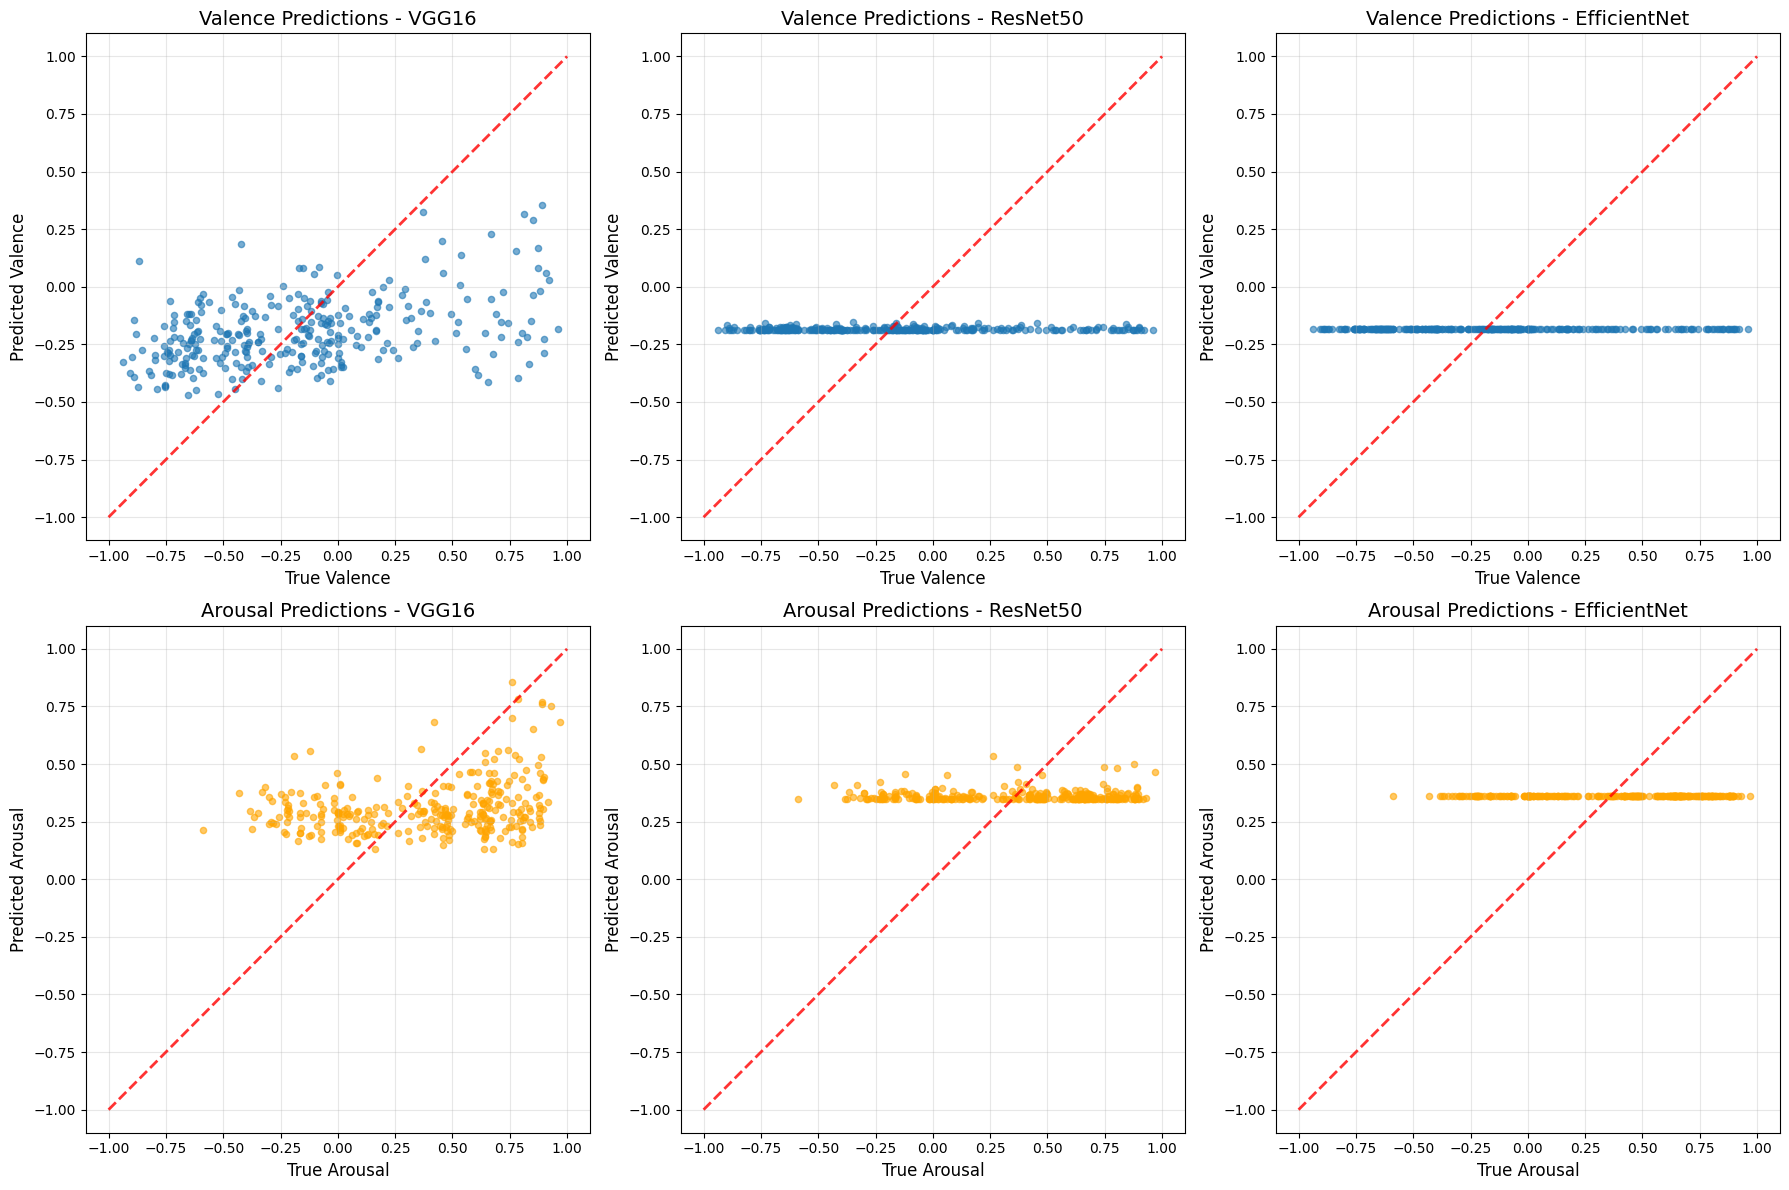

In [ ]:

# Scatter plots for valence and arousal predictions
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for i, model_name in enumerate(model_names):
    model_results = results[model_name]

    # Valence scatter plot
    axes[0, i].scatter(y_test_val, model_results['predictions']['valence'],
                      alpha=0.6, s=20)
    axes[0, i].plot([-1, 1], [-1, 1], 'r--', lw=2, alpha=0.8)
    axes[0, i].set_xlabel('True Valence', fontsize=12)
    axes[0, i].set_ylabel('Predicted Valence', fontsize=12)
    axes[0, i].set_title(f'Valence Predictions - {model_name}', fontsize=14)
    axes[0, i].grid(True, alpha=0.3)
    axes[0, i].set_xlim([-1.1, 1.1])
    axes[0, i].set_ylim([-1.1, 1.1])

    # Arousal scatter plot
    axes[1, i].scatter(y_test_ar, model_results['predictions']['arousal'],
                      alpha=0.6, s=20, color='orange')
    axes[1, i].plot([-1, 1], [-1, 1], 'r--', lw=2, alpha=0.8)
    axes[1, i].set_xlabel('True Arousal', fontsize=12)
    axes[1, i].set_ylabel('Predicted Arousal', fontsize=12)
    axes[1, i].set_title(f'Arousal Predictions - {model_name}', fontsize=14)
    axes[1, i].grid(True, alpha=0.3)
    axes[1, i].set_xlim([-1.1, 1.1])
    axes[1, i].set_ylim([-1.1, 1.1])

plt.tight_layout()
plt.show()


In [ ]:

# Create comprehensive results DataFrame
results_data = []
for model_name in results.keys():
    model_results = results[model_name]['metrics']
    row = {
        'Model': model_name,
        'Expression_Accuracy': model_results['expression']['accuracy'],
        'Expression_F1': model_results['expression']['f1_score'],
        'Expression_Kappa': model_results['expression']['cohen_kappa'],
        'Valence_RMSE': model_results['valence']['rmse'],
        'Valence_Correlation': model_results['valence']['correlation'],
        'Valence_SAGR': model_results['valence']['sagr'],
        'Valence_CCC': model_results['valence']['ccc'],
        'Arousal_RMSE': model_results['arousal']['rmse'],
        'Arousal_Correlation': model_results['arousal']['correlation'],
        'Arousal_SAGR': model_results['arousal']['sagr'],
        'Arousal_CCC': model_results['arousal']['ccc']
    }
    results_data.append(row)

results_df = pd.DataFrame(results_data)

print("\n" + "="*80)
print("FINAL RESULTS SUMMARY")
print("="*80)
print(results_df.round(4).to_string(index=False))

# Save results
results_df.to_csv('facial_expression_results.csv', index=False)
print("\nResults saved to 'facial_expression_results.csv'")

# Model ranking
print("\nMODEL RANKING:")
print("-" * 40)
ranking_metrics = ['Expression_Accuracy', 'Valence_Correlation', 'Arousal_Correlation']

for metric in ranking_metrics:
    sorted_models = results_df.sort_values(metric, ascending=False)
    print(f"\nBy {metric}:")
    for i, (_, row) in enumerate(sorted_models.iterrows(), 1):
        print(f"  {i}. {row['Model']}: {row[metric]:.4f}")

print("\n" + "="*80)
print("ASSIGNMENT COMPLETED SUCCESSFULLY!")
print("="*80)
print("Generated Files:")
print("1. facial_expression_results.csv - Comprehensive results")
print("2. best_VGG16.h5 - Best VGG16 model")
print("3. best_ResNet50.h5 - Best ResNet50 model")
print("4. best_EfficientNet.h5 - Best EfficientNet model")
print("\nAll visualizations and analysis plots have been displayed above.")


FINAL RESULTS SUMMARY
       Model  Expression_Accuracy  Expression_F1  Expression_Kappa  Valence_RMSE  Valence_Correlation  Valence_SAGR  Valence_CCC  Arousal_RMSE  Arousal_Correlation  Arousal_SAGR  Arousal_CCC
       VGG16               0.2800         0.2715            0.1755        0.4343               0.4177        0.7200       0.2343        0.3655               0.2658        0.7833       0.1475
    ResNet50               0.1367         0.0714            0.0065        0.4736               0.0307        0.6933       0.0009        0.3735               0.0121        0.7833       0.0016
EfficientNet               0.1333         0.0294            0.0000        0.4737               0.0000        0.6933       0.0000        0.3730               0.0000        0.7833       0.0000

Results saved to 'facial_expression_results.csv'

MODEL RANKING:
----------------------------------------

By Expression_Accuracy:
  1. VGG16: 0.2800
  2. ResNet50: 0.1367
  3. EfficientNet: 0.1333

By Valence_Co